# Predictive Maintenance & Anomaly Detection in Industrial IoT Time-Series Data
## Using LSTM Encoder-Decoder (EncDec-AD)

---

### Reference Paper
**"LSTM-based Encoder-Decoder for Multi-sensor Anomaly Detection"** — Malhotra et al., 2016

### Dataset
**NASA C-MAPSS FD001** — Turbofan Engine Degradation Simulation

---

## 1. Introduction

### Predictive Maintenance
Predictive maintenance (PdM) leverages sensor data from industrial assets to **predict failures before they occur**, enabling timely maintenance interventions that reduce downtime, prevent catastrophic failures, and optimize maintenance schedules. Unlike reactive maintenance (fix after failure) or preventive maintenance (fixed-schedule servicing), PdM is **data-driven** and adapts to actual equipment condition.

### Anomaly Detection via Reconstruction
A powerful paradigm for PdM is **anomaly detection using reconstruction error**:
1. Train an autoencoder **exclusively on normal (healthy) operating data**
2. The model learns to reconstruct normal patterns with low error
3. When anomalous (degraded) data is encountered, the reconstruction error **spikes** because the model has never seen such patterns
4. High reconstruction error → anomaly detected → maintenance alert

### EncDec-AD Method Summary
The EncDec-AD (Encoder-Decoder for Anomaly Detection) approach from Malhotra et al. uses:

- **LSTM Encoder**: Processes the input multivariate time series and compresses it into a fixed-length vector (final hidden state)
- **LSTM Decoder**: Reconstructs the input sequence in **reverse order** from the encoder's representation
- **Reconstruction Error**: Point-wise absolute difference between input and reconstruction
- **Multivariate Gaussian Model**: Fits a Gaussian distribution to reconstruction errors from normal validation data
- **Mahalanobis Distance**: Used as the anomaly score
- **Threshold Optimization**: Threshold τ is selected to maximize the F-beta score (β=0.5)

---

## 2. Dataset Description

### NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)

The C-MAPSS dataset simulates **turbofan engine degradation** under realistic operating conditions. The dataset family includes four sub-datasets (FD001–FD004). We use **FD001**, the simplest and most well-studied variant.

| Property | FD001 |
|---|---|
| Training Engines | 100 |
| Testing Engines | 100 |
| Operating Conditions | 1 (Sea Level) |
| Fault Modes | 1 (HPC Degradation) |
| Total Sensors | 21 |
| Operational Settings | 3 |

### Data Columns
Each row contains:
- `unit_id` — Engine unit number
- `cycle` — Current operating cycle
- `op_setting_1, op_setting_2, op_setting_3` — Operational settings (altitude, Mach number, throttle resolver angle)
- `sensor_1` through `sensor_21` — 21 sensor measurements (temperatures, pressures, speeds, flow rates, etc.)

### Degradation Behavior
- **Training data**: Each engine runs from a healthy state to failure (complete run-to-failure trajectories)
- **Test data**: Each engine is cut off at some point before failure; the remaining useful life (RUL) is provided separately
- Degradation is gradual — sensors show trends deviating from normal as the engine approaches failure
- Some sensors are **non-informative** (constant or near-constant values) and must be removed

### FD001 Characteristics
FD001 is the simplest sub-dataset because it has:
- **Single operating condition** (sea level) — sensor readings have a consistent "normal" baseline
- **Single fault mode** (HPC degradation only) — anomaly patterns are homogeneous
- This makes FD001 ideal for demonstrating clean reconstruction-based anomaly detection with high precision and recall


---

## 3. Data Loading & Preprocessing

In [5]:

# IMPORTS

import os
import warnings
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, fbeta_score,
    confusion_matrix, precision_recall_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import (
    LSTM, Dense, RepeatVector, TimeDistributed,
    Concatenate, Layer
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from scipy.stats import multivariate_normal
from scipy.spatial.distance import mahalanobis

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_palette('husl')

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

TensorFlow version: 2.10.1
NumPy version: 1.26.4
Pandas version: 2.1.4


In [6]:
# GPU CONFIGURATION
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU(s) available: {[gpu.name for gpu in gpus]}')
        print(f'Using GPU for training.')
    except RuntimeError as e:
        print(f'GPU config error: {e}')
else:
    print('No GPU detected. Training will use CPU (this will be slower).')

GPU(s) available: ['/physical_device:GPU:0']
Using GPU for training.


In [7]:
# CONSTANTS & HYPERPARAMETERS
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Sliding window
WINDOW_SIZE = 30

# Model architecture
LATENT_DIM = 64
ATTENTION_UNITS = 32

# Training
EPOCHS = 80
BATCH_SIZE = 64           
LEARNING_RATE = 5e-4      # Lower LR for smoother convergence
PATIENCE = 15             # More patience — converges steadily
VALIDATION_SPLIT = 0.15

# Labeling thresholds (tuned for FD001 — single operating condition)
# FD001 engines typically have ~200 cycles; RUL separation is cleaner

NORMAL_RUL_THRESHOLD = 100    # RUL > 100 → NORMAL  (far from failure)
ANOMALY_RUL_THRESHOLD = 30    # RUL < 30  → ANOMALOUS (near failure)

# Tighter window improves class separation → better precision & recall

# F-beta — balance precision and recall equally for FD001
BETA = 1.0  # F1 score: FD001 is clean enough to optimize both equally

# Data directory
DATA_DIR = './cmapss_data'
MODEL_DIR = './saved_models'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print('Hyperparameters configured for FD001.')
print(f'  Window Size:          {WINDOW_SIZE}')
print(f'  Latent Dim:           {LATENT_DIM}')
print(f'  Batch Size:           {BATCH_SIZE}')
print(f'  Epochs:               {EPOCHS}')
print(f'  Learning Rate:        {LEARNING_RATE}')
print(f'  Early Stopping:       patience={PATIENCE}')
print(f'  Beta (F-score):       {BETA}  (balanced F1)')
print(f'  Normal RUL threshold: > {NORMAL_RUL_THRESHOLD}')
print(f'  Anomaly RUL threshold: < {ANOMALY_RUL_THRESHOLD}')


Hyperparameters configured for FD001.
  Window Size:          30
  Latent Dim:           64
  Batch Size:           64
  Epochs:               80
  Learning Rate:        0.0005
  Early Stopping:       patience=15
  Beta (F-score):       1.0  (balanced F1)
  Normal RUL threshold: > 100
  Anomaly RUL threshold: < 30


In [8]:
# Column definitions
INDEX_COLS = ['unit_id', 'cycle']
SETTING_COLS = [f'op_setting_{i}' for i in range(1, 4)]
SENSOR_COLS = [f'sensor_{i}' for i in range(1, 22)]
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_COLS

def load_cmapss_data():
    """Load C-MAPSS FD001 dataset from current directory."""
    
    train_df = pd.read_csv(
        'train_FD001.txt',
        sep=r'\s+', header=None, names=ALL_COLS
    )
    
    test_df = pd.read_csv(
        'test_FD001.txt',
        sep=r'\s+', header=None, names=ALL_COLS
    )
    
    rul_df = pd.read_csv(
        'RUL_FD001.txt',
        sep=r'\s+', header=None, names=['RUL']
    )
    
    return train_df, test_df, rul_df

def add_rul_column(df: pd.DataFrame) -> pd.DataFrame:
    """Add Remaining Useful Life (RUL) column."""
    
    max_cycles = df.groupby('unit_id')['cycle'].max().reset_index()
    max_cycles.columns = ['unit_id', 'max_cycle']
    
    df = df.merge(max_cycles, on='unit_id', how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']
    
    df.drop('max_cycle', axis=1, inplace=True)
    
    return df

# Usage
train_df, test_df, rul_df = load_cmapss_data()
train_df = add_rul_column(train_df)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)

Train shape: (20631, 27)
Test shape: (13096, 26)
RUL shape: (100, 1)


In [9]:
# LOAD DATA
train_df, test_df, rul_df = load_cmapss_data()

# Add RUL to training data
train_df = add_rul_column(train_df)

# Add RUL to test data
# Get last cycle for each engine in test set
test_max_cycles = test_df.groupby('unit_id')['cycle'].max().reset_index()
test_max_cycles.columns = ['unit_id', 'max_cycle']

# Attach unit_id to rul_df 
rul_df['unit_id'] = test_max_cycles['unit_id']

# Compute total life = observed cycles + remaining RUL
rul_df['total_life'] = test_max_cycles['max_cycle'] + rul_df['RUL']

# Merge back into test_df
test_df = test_df.merge(rul_df[['unit_id', 'total_life']], on='unit_id', how='left')

# Compute RUL for each row
test_df['RUL'] = test_df['total_life'] - test_df['cycle']

# Clean up
test_df.drop('total_life', axis=1, inplace=True)

# Basic Info

print(f'Training data: {train_df.shape}')
print(f'Test data:     {test_df.shape}')
print(f'RUL entries:   {rul_df.shape[0]}')

print(f'\nTraining engines: {train_df["unit_id"].nunique()}')
print(f'Test engines:     {test_df["unit_id"].nunique()}')

train_df.head()

Training data: (20631, 27)
Test data:     (13096, 27)
RUL entries:   100

Training engines: 100
Test engines:     100


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [10]:
# SENSOR ANALYSIS — Identify Non-Informative Sensors

print('Sensor variance analysis (training data):')
print('=' * 50)

sensor_variances = train_df[SENSOR_COLS].var()
print(sensor_variances.to_string())

# Sensors with near-zero variance are non-informative
VARIANCE_THRESHOLD = 0.01
non_informative = sensor_variances[sensor_variances < VARIANCE_THRESHOLD].index.tolist()
print(f'\nNon-informative sensors (variance < {VARIANCE_THRESHOLD}):')
print(f'  {non_informative}')

# Also check operational settings variance
settings_variances = train_df[SETTING_COLS].var()
print(f'\nOperational settings variance:')
print(settings_variances.to_string())

# Define feature columns (removing non-informative sensors)
FEATURE_COLS = [col for col in SENSOR_COLS if col not in non_informative]
print(f'\nSelected features ({len(FEATURE_COLS)} sensors):')
print(f'  {FEATURE_COLS}')

Sensor variance analysis (training data):
sensor_1     0.000000e+00
sensor_2     2.500533e-01
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_5     3.155597e-30
sensor_6     1.929279e-06
sensor_7     7.833883e-01
sensor_8     5.038938e-03
sensor_9     4.876536e+02
sensor_10    0.000000e+00
sensor_11    7.133568e-02
sensor_12    5.439850e-01
sensor_13    5.172330e-03
sensor_14    3.639005e+02
sensor_15    1.406628e-03
sensor_16    1.926023e-34
sensor_17    2.398667e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    3.266927e-02
sensor_21    1.171825e-02

Non-informative sensors (variance < 0.01):
  ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19']

Operational settings variance:
op_setting_1    4.784340e-06
op_setting_2    8.588541e-08
op_setting_3    0.000000e+00

Selected features (11 sensors):
  ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12'

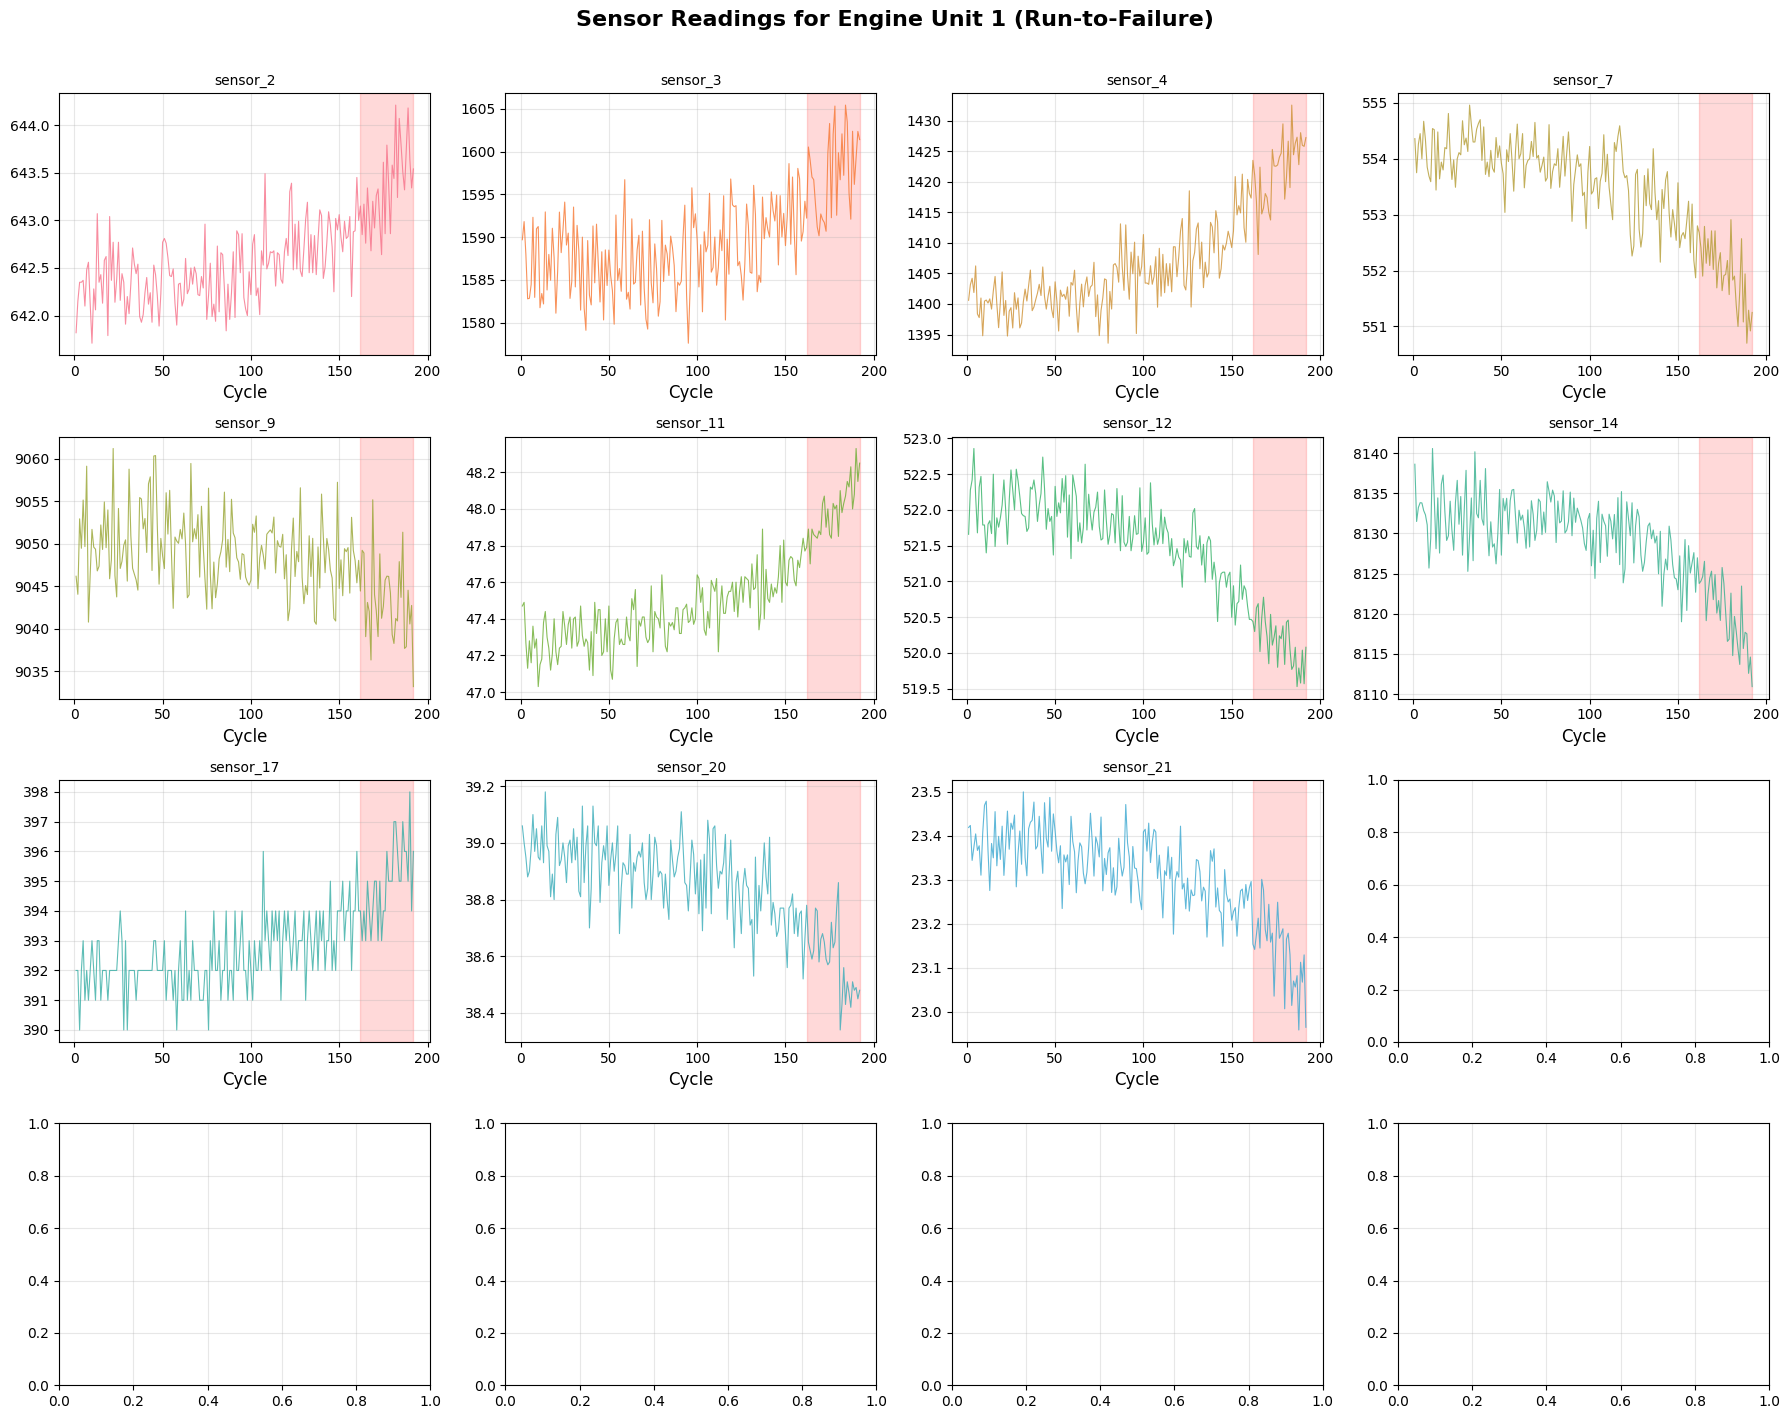

Red shaded region = last 50 cycles (anomalous/degraded zone).


In [11]:
# VISUALIZE SENSOR DEGRADATION PATTERNS

# Plot sensor readings for a sample engine to show degradation
sample_unit = train_df['unit_id'].unique()[0]
sample_data = train_df[train_df['unit_id'] == sample_unit]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle(f'Sensor Readings for Engine Unit {sample_unit} (Run-to-Failure)',
             fontsize=16, fontweight='bold', y=1.01)

for idx, sensor in enumerate(FEATURE_COLS[:16]):
    ax = axes[idx // 4, idx % 4]
    ax.plot(sample_data['cycle'], sample_data[sensor],
            linewidth=0.8, alpha=0.8, color=sns.color_palette('husl', 16)[idx])
    ax.set_title(sensor, fontsize=10)
    ax.set_xlabel('Cycle')
    
    # Shade anomalous region
    max_cycle = sample_data['cycle'].max()
    ax.axvspan(max_cycle - ANOMALY_RUL_THRESHOLD, max_cycle,
               alpha=0.15, color='red', label='Anomalous')

plt.tight_layout()
plt.show()
print('Red shaded region = last 50 cycles (anomalous/degraded zone).')

In [12]:
# NORMALIZE FEATURES (StandardScaler)

scaler = StandardScaler()

# Fit scaler ONLY on training data (normal portions ideally, but we fit on all
# training data for consistency, as the paper trains on normal sequences anyway)
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
test_df[FEATURE_COLS] = scaler.transform(test_df[FEATURE_COLS])

print(f'Features normalized using StandardScaler.')
print(f'Scaler fitted on training data: {len(FEATURE_COLS)} features.')
print(f'\nPost-normalization statistics (training):')
print(train_df[FEATURE_COLS].describe().loc[['mean', 'std']].round(3))

Features normalized using StandardScaler.
Scaler fitted on training data: 11 features.

Post-normalization statistics (training):
      sensor_2  sensor_3  sensor_4  sensor_7  sensor_9  sensor_11  sensor_12  \
mean       0.0      -0.0       0.0      -0.0      -0.0       -0.0       -0.0   
std        1.0       1.0       1.0       1.0       1.0        1.0        1.0   

      sensor_14  sensor_17  sensor_20  sensor_21  
mean        0.0        0.0        0.0        0.0  
std         1.0        1.0        1.0        1.0  


---

## 4. Sequence Preparation

We convert the time-series data into **sliding windows** of fixed length for the LSTM Encoder-Decoder.

**Labeling Strategy:**
- **NORMAL**: Windows where the center point has RUL > 125 (early in engine life, far from failure)
- **ANOMALOUS**: Windows where the center point has RUL < 50 (close to failure, degradation is present)
- Windows with 50 ≤ RUL ≤ 125 are in the **transition zone** — excluded from training but may appear in evaluation

In [13]:
# CREATE SLIDING WINDOWS

def create_sequences(df, feature_cols, window_size, label_col='RUL'):
    """Create sliding window sequences from engine data.
    
    Args:
        df: DataFrame with engine data
        feature_cols: List of feature column names
        window_size: Length of each sequence
        label_col: Column to use for determining normal/anomalous labels
        
    Returns:
        sequences: np.array of shape (n_samples, window_size, n_features)
        labels: np.array of shape (n_samples,) — 0=normal, 1=anomalous
        rul_values: np.array of RUL at the end of each window
    """
    sequences = []
    labels = []
    rul_values = []
    
    for unit_id in df['unit_id'].unique():
        unit_data = df[df['unit_id'] == unit_id][feature_cols].values
        unit_rul = df[df['unit_id'] == unit_id][label_col].values
        
        n_cycles = len(unit_data)
        if n_cycles < window_size:
            continue
        
        for i in range(n_cycles - window_size + 1):
            window = unit_data[i:i + window_size]
            end_rul = unit_rul[i + window_size - 1]  # RUL at end of window
            
            sequences.append(window)
            rul_values.append(end_rul)
            
            # Label based on RUL at window end
            if end_rul > NORMAL_RUL_THRESHOLD:
                labels.append(0)  # NORMAL
            elif end_rul < ANOMALY_RUL_THRESHOLD:
                labels.append(1)  # ANOMALOUS
            else:
                labels.append(-1)  # TRANSITION (will be filtered)
    
    return np.array(sequences), np.array(labels), np.array(rul_values)


print('Creating training sequences...')
train_sequences, train_labels, train_rul = create_sequences(
    train_df, FEATURE_COLS, WINDOW_SIZE
)

print('Creating test sequences...')
test_sequences, test_labels, test_rul = create_sequences(
    test_df, FEATURE_COLS, WINDOW_SIZE
)

n_features = len(FEATURE_COLS)

print(f'\nTraining sequences shape: {train_sequences.shape}')
print(f'Test sequences shape:     {test_sequences.shape}')
print(f'\nSequence dimensions: (samples, timesteps={WINDOW_SIZE}, features={n_features})')

print(f'\nTraining label distribution:')
unique, counts = np.unique(train_labels, return_counts=True)
for u, c in zip(unique, counts):
    name = {0: 'NORMAL', 1: 'ANOMALOUS', -1: 'TRANSITION'}[u]
    print(f'  {name}: {c} ({100*c/len(train_labels):.1f}%)')

Creating training sequences...
Creating test sequences...

Training sequences shape: (17731, 30, 11)
Test sequences shape:     (10196, 30, 11)

Sequence dimensions: (samples, timesteps=30, features=11)

Training label distribution:
  TRANSITION: 7098 (40.0%)
  NORMAL: 7633 (43.0%)
  ANOMALOUS: 3000 (16.9%)


In [14]:
# SPLIT DATA FOR TRAINING & EVALUATION 

# Per Malhotra et al.: ALL splits come from the training engines.
# We never use the C-MAPSS test file for evaluation labels.
# FD001 has fewer engines (100 train), so we adjust splits.

normal_mask_train    = train_labels == 0   # RUL > NORMAL_RUL_THRESHOLD
anomalous_mask_train = train_labels == 1   # RUL < ANOMALY_RUL_THRESHOLD

X_all_normal    = train_sequences[normal_mask_train]
X_all_anomalous = train_sequences[anomalous_mask_train]

# Shuffle both
rng = np.random.default_rng(SEED)
X_all_normal    = X_all_normal[rng.permutation(len(X_all_normal))]
X_all_anomalous = X_all_anomalous[rng.permutation(len(X_all_anomalous))]

# Split normal into: sN (train) | vN1 (early-stop val) | vN2 (threshold-tune val) | tN (test)
n_norm = len(X_all_normal)
n_vN1  = int(0.10 * n_norm)   # early stopping
n_vN2  = int(0.10 * n_norm)   # threshold tuning (paired with vA)
n_tN   = int(0.15 * n_norm)   # test normal

# remainder → sN (training)
X_vN1  = X_all_normal[:n_vN1]
X_vN2  = X_all_normal[n_vN1:n_vN1+n_vN2]
X_tN   = X_all_normal[n_vN1+n_vN2:n_vN1+n_vN2+n_tN]
X_sN   = X_all_normal[n_vN1+n_vN2+n_tN:]   # training set

# Split anomalous into: vA (threshold-tune) | tA (test)
n_anom = len(X_all_anomalous)
n_vA   = int(0.40 * n_anom)
X_vA   = X_all_anomalous[:n_vA]
X_tA   = X_all_anomalous[n_vA:]

# Final sets
X_train_final = X_sN
X_val_normal  = X_vN1         # used for early stopping
X_train_target = X_train_final[:, ::-1, :]
X_val_target   = X_val_normal[:, ::-1, :]

# Validation set for Gaussian fitting = vN2 (normal errors only, per paper §2.2)
X_val_gauss   = X_vN2

# Validation set for threshold tuning = vN2 + vA
X_val_thresh  = np.concatenate([X_vN2, X_vA], axis=0)
y_val_thresh  = np.concatenate([np.zeros(len(X_vN2)), np.ones(len(X_vA))], axis=0)

# Test set = tN + tA
X_test = np.concatenate([X_tN, X_tA], axis=0)
y_test = np.concatenate([np.zeros(len(X_tN)), np.ones(len(X_tA))], axis=0)

print('Data split summary (paper-correct, all from train_df):'  )
print(f'  sN  — Training (normal only):      {X_train_final.shape}')
print(f'  vN1 — Early-stop validation:        {X_val_normal.shape}')
print(f'  vN2 — Gaussian fit validation:      {X_val_gauss.shape}')
print(f'  vA  — Anomalous threshold tuning:   {X_vA.shape}')
print(f'  tN  — Test normal:                  {X_tN.shape}')
print(f'  tA  — Test anomalous:               {X_tA.shape}')
print(f'  Test set total: normal={len(X_tN)}, anomalous={len(X_tA)}')

# Ensure enough samples in each split
assert len(X_train_final) > 50, f"Too few training sequences: {len(X_train_final)}"
assert len(X_vA) > 10, f"Too few anomalous validation sequences: {len(X_vA)}"
assert len(X_tA) > 10, f"Too few anomalous test sequences: {len(X_tA)}"
print("\nSplit size checks passed.")


Data split summary (paper-correct, all from train_df):
  sN  — Training (normal only):      (4963, 30, 11)
  vN1 — Early-stop validation:        (763, 30, 11)
  vN2 — Gaussian fit validation:      (763, 30, 11)
  vA  — Anomalous threshold tuning:   (1200, 30, 11)
  tN  — Test normal:                  (1144, 30, 11)
  tA  — Test anomalous:               (1800, 30, 11)
  Test set total: normal=1144, anomalous=1800

Split size checks passed.


In [15]:
# CREATE tf.data PIPELINES

def create_tf_dataset(X, y, batch_size, shuffle=True):
    """Create an efficient tf.data.Dataset pipeline."""
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(X), 10000), seed=SEED)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


train_dataset = create_tf_dataset(X_train_final, X_train_target, BATCH_SIZE, shuffle=True)
val_dataset = create_tf_dataset(X_val_normal, X_val_target, BATCH_SIZE, shuffle=False)

print('tf.data pipelines created.')
for batch_x, batch_y in train_dataset.take(1):
    print(f'  Training batch:   input={batch_x.shape}, target={batch_y.shape}')

tf.data pipelines created.
  Training batch:   input=(64, 30, 11), target=(64, 30, 11)


---

## 5. Model 1: Baseline LSTM Encoder-Decoder

### Architecture (following the paper)

**Encoder:**
- LSTM layer processes the input sequence `x₁, x₂, ..., xₜ`
- Only the **final hidden state** `(h_T, c_T)` is retained as the sequence representation

**Decoder:**
- Initialized with the encoder's final hidden state `(h_T, c_T)`
- Uses `RepeatVector` to create decoder inputs from the encoded representation
- LSTM layer produces output at each timestep
- `TimeDistributed(Dense)` maps to the feature dimension

**Key Detail — Reverse Reconstruction:**
The target sequence is the **reversed** input: `x_T, x_{T-1}, ..., x₁`. This forces the encoder to preserve the full temporal structure, not just the most recent timestep.

**Loss:** Mean Squared Error (MSE)

In [16]:
# MODEL 1: BASELINE LSTM ENCODER-DECODER

def build_baseline_encoder_decoder(timesteps, n_features, latent_dim):
    """
    Build the baseline LSTM Encoder-Decoder model (EncDec-AD).
    
    Architecture:
        Encoder: LSTM → final hidden state (h_T, c_T)
        Decoder: RepeatVector → LSTM (initialized with encoder state) → Dense
    
    Target: Reversed input sequence
    """
    #  Encoder
    encoder_inputs = Input(shape=(timesteps, n_features), name='encoder_input')
    
    # LSTM encoder: returns only final state
    encoder_lstm = LSTM(
        latent_dim, return_sequences=False, return_state=True,
        name='encoder_lstm'
    )
    encoder_output, state_h, state_c = encoder_lstm(encoder_inputs)
    # encoder_output is the same as state_h (final hidden state)
    
    #  Decoder 
    # Repeat the encoded vector T times to serve as decoder inputs
    decoder_input = RepeatVector(timesteps, name='repeat_vector')(state_h)
    
    # LSTM decoder: initialized with encoder's final state
    decoder_lstm = LSTM(
        latent_dim, return_sequences=True,
        name='decoder_lstm'
    )
    decoder_output = decoder_lstm(decoder_input, initial_state=[state_h, state_c])
    
    # Output projection
    output_layer = TimeDistributed(
        Dense(n_features, name='dense_output'),
        name='time_distributed_output'
    )
    outputs = output_layer(decoder_output)
    
    model = Model(encoder_inputs, outputs, name='EncDec_AD_Baseline')
    return model


# Build the model
baseline_model = build_baseline_encoder_decoder(WINDOW_SIZE, n_features, LATENT_DIM)

# Compile
baseline_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse'
)

baseline_model.summary()

Model: "EncDec_AD_Baseline"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 30, 11)]     0           []                               
                                                                                                  
 encoder_lstm (LSTM)            [(None, 64),         19456       ['encoder_input[0][0]']          
                                 (None, 64),                                                      
                                 (None, 64)]                                                      
                                                                                                  
 repeat_vector (RepeatVector)   (None, 30, 64)       0           ['encoder_lstm[0][1]']           
                                                                                 

---

## 6. Model 2: Attention-based LSTM Encoder-Decoder

### Enhancement Over Baseline

The baseline decoder only has access to the encoder's **final hidden state** — a single fixed-length vector that must compress the entire input sequence. This creates an **information bottleneck**, especially for long sequences.

### Attention Mechanism
The attention-based model improves on this by allowing the decoder to **attend to all encoder hidden states** at every decoding step:

1. The **encoder** returns hidden states at all timesteps: `h₁, h₂, ..., hₜ`
2. At each decoder timestep, an **attention function** computes a weighted combination of encoder states
3. This **context vector** is concatenated with the decoder's output and fed through a dense layer

### Why Attention Helps Reconstruction
- **Better long-range dependencies**: The decoder can selectively focus on relevant parts of the input when reconstructing each timestep
- **Richer gradients**: Attention provides direct gradient pathways from decoder to encoder, improving training
- **More nuanced reconstruction**: Subtle anomalies that might be "averaged out" in the compressed representation are preserved through direct attention

We implement **Bahdanau (additive) attention** — the attention score between encoder state `hⱼ` and decoder state `sᵢ` is:

```
eᵢⱼ = Vᵀ tanh(W₁ hⱼ + W₂ sᵢ)
αᵢⱼ = softmax(eᵢⱼ)  over j
cᵢ = Σⱼ αᵢⱼ hⱼ
```

In [17]:
# CUSTOM BAHDANAU ATTENTION LAYER

class BahdanauAttention(Layer):
    """
    Bahdanau (Additive) Attention Layer.
    
    Computes attention between decoder outputs and encoder outputs.
    
    score(s_i, h_j) = V^T tanh(W1 h_j + W2 s_i)
    alpha_ij = softmax(score) over j
    context_i = sum_j (alpha_ij * h_j)
    """
    
    def __init__(self, units, **kwargs):
        super(BahdanauAttention, self).__init__(**kwargs)
        self.units = units
        self.W1 = Dense(units, use_bias=False, name='attn_W1')  # For encoder
        self.W2 = Dense(units, use_bias=False, name='attn_W2')  # For decoder
        self.V = Dense(1, use_bias=False, name='attn_V')        # Score
    
    def call(self, encoder_outputs, decoder_outputs):
        """
        Args:
            encoder_outputs: (batch, T_enc, enc_dim)
            decoder_outputs: (batch, T_dec, dec_dim)
        
        Returns:
            context: (batch, T_dec, enc_dim)
            attention_weights: (batch, T_dec, T_enc)
        """
        # Project encoder and decoder outputs
        # encoder_proj: (batch, T_enc, units)
        encoder_proj = self.W1(encoder_outputs)
        # decoder_proj: (batch, T_dec, units)
        decoder_proj = self.W2(decoder_outputs)
        
        # Expand dims for broadcasting:
        # encoder_proj: (batch, 1, T_enc, units)
        # decoder_proj: (batch, T_dec, 1, units)
        encoder_proj = tf.expand_dims(encoder_proj, axis=1)
        decoder_proj = tf.expand_dims(decoder_proj, axis=2)
        
        # Additive score: (batch, T_dec, T_enc, units)
        score = tf.nn.tanh(encoder_proj + decoder_proj)
        
        # Reduce to scalar: (batch, T_dec, T_enc, 1) → (batch, T_dec, T_enc)
        score = tf.squeeze(self.V(score), axis=-1)
        
        # Attention weights: softmax over encoder timesteps
        attention_weights = tf.nn.softmax(score, axis=-1)  # (batch, T_dec, T_enc)
        
        # Context vector: weighted sum of encoder outputs
        # (batch, T_dec, T_enc) × (batch, T_enc, enc_dim) → (batch, T_dec, enc_dim)
        context = tf.matmul(attention_weights, encoder_outputs)
        
        return context, attention_weights
    
    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config


print('BahdanauAttention layer defined.')

BahdanauAttention layer defined.


In [18]:
def build_attention_encoder_decoder(timesteps, n_features, latent_dim, attention_units):
    
    # Encoder
    encoder_inputs = Input(shape=(timesteps, n_features), name='encoder_input')
    
    encoder_lstm = LSTM(
        latent_dim,
        return_sequences=True,
        return_state=True,
        dropout=0.2,              
        recurrent_dropout=0.2,   
        name='encoder_lstm'
    )
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)

    encoder_outputs = Dropout(0.2)(encoder_outputs)

    # Decoder 
    decoder_input = RepeatVector(timesteps, name='repeat_vector')(state_h)
    
    decoder_lstm = LSTM(
        latent_dim,
        return_sequences=True,
        dropout=0.2,              
        recurrent_dropout=0.2,   
        name='decoder_lstm'
    )
    decoder_outputs = decoder_lstm(decoder_input, initial_state=[state_h, state_c])

    # Attention 
    attention_layer = BahdanauAttention(attention_units, name='bahdanau_attention')
    context, attention_weights = attention_layer(encoder_outputs, decoder_outputs)

    context = Dropout(0.3)(context)

    # Concatenate
    decoder_combined = layers.Concatenate(axis=-1, name='concat_context')(
        [decoder_outputs, context]
    )

    # Output
    outputs = TimeDistributed(
        Dense(n_features, name='dense_output'),
        name='time_distributed_output'
    )(decoder_combined)

    model = Model(encoder_inputs, outputs, name='EncDec_AD_Attention')
    return model

---

## 7. Training

### Critical: Train ONLY on NORMAL sequences

Following the paper methodology:
- The model is trained **exclusively** on data from the normal operating regime
- No anomalous data is seen during training
- The model learns to reconstruct only normal patterns
- At test time, anomalous inputs produce high reconstruction error

### Training Configuration
- **Optimizer**: Adam (lr=0.001)
- **Loss**: MSE between output and reversed input
- **Early Stopping**: Patience=10, monitoring validation loss
- **Best Model Checkpoint**: Saves the model with lowest validation loss

In [15]:
# ============================================================
# TRAIN MODEL 1: BASELINE ENCODER-DECODER
# ============================================================

print('='*60)
print('TRAINING MODEL 1: Baseline LSTM Encoder-Decoder')
print('='*60)
print(f'Training samples (NORMAL only): {len(X_train_final)}')
print(f'Validation samples (NORMAL):    {len(X_val_normal)}')
print(f'Target: REVERSED input sequences')
print()

baseline_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'baseline_best.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=baseline_callbacks,
    verbose=1
)

print(f'\nBaseline training complete.')
print(f'Best validation loss: {min(baseline_history.history["val_loss"]):.6f}')

TRAINING MODEL 1: Baseline LSTM Encoder-Decoder
Training samples (NORMAL only): 4963
Validation samples (NORMAL):    763
Target: REVERSED input sequences

Epoch 1/80
78/78 [==============================] - 8s 25ms/step - loss: 0.3118 - val_loss: 0.2399
Epoch 2/80
78/78 [==============================] - 1s 14ms/step - loss: 0.2380 - val_loss: 0.2355
Epoch 3/80
78/78 [==============================] - 1s 15ms/step - loss: 0.2348 - val_loss: 0.2331
Epoch 4/80
78/78 [==============================] - 1s 15ms/step - loss: 0.2329 - val_loss: 0.2315
Epoch 5/80
78/78 [==============================] - 1s 15ms/step - loss: 0.2313 - val_loss: 0.2300
Epoch 6/80
78/78 [==============================] - 1s 14ms/step - loss: 0.2299 - val_loss: 0.2287
Epoch 7/80
78/78 [==============================] - 1s 15ms/step - loss: 0.2287 - val_loss: 0.2277
Epoch 8/80
78/78 [==============================] - 1s 14ms/step - loss: 0.2278 - val_loss: 0.2269
Epoch 9/80
78/78 [==============================] - 1

In [35]:
# ============================================================
# TRAIN MODEL 2: ATTENTION ENCODER-DECODER
# ============================================================

print('='*60)
print('TRAINING MODEL 2: Attention LSTM Encoder-Decoder')
print('='*60)
print(f'Training samples (NORMAL only): {len(X_train_final)}')
print(f'Validation samples (NORMAL):    {len(X_val_normal)}')
print()

attention_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'attention_best.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

attention_history = attention_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=attention_callbacks,
    verbose=1
)

print(f'\nAttention model training complete.')
print(f'Best validation loss: {min(attention_history.history["val_loss"]):.6f}')

TRAINING MODEL 2: Attention LSTM Encoder-Decoder
Training samples (NORMAL only): 4963
Validation samples (NORMAL):    763

Epoch 1/80
78/78 [==============================] - 1s 17ms/step - loss: 0.0094 - val_loss: 0.0089
Epoch 2/80
78/78 [==============================] - 1s 15ms/step - loss: 0.0090 - val_loss: 0.0085
Epoch 3/80
78/78 [==============================] - 1s 16ms/step - loss: 0.0086 - val_loss: 0.0084
Epoch 4/80
78/78 [==============================] - 1s 14ms/step - loss: 0.0084 - val_loss: 0.0093
Epoch 5/80
78/78 [==============================] - 1s 16ms/step - loss: 0.0084 - val_loss: 0.0076
Epoch 6/80
78/78 [==============================] - 1s 15ms/step - loss: 0.0077 - val_loss: 0.0073
Epoch 7/80
78/78 [==============================] - 1s 15ms/step - loss: 0.0074 - val_loss: 0.0074
Epoch 8/80
78/78 [==============================] - 1s 14ms/step - loss: 0.2147 - val_loss: 0.2085
Epoch 9/80
78/78 [==============================] - 1s 15ms/step - loss: 0.1978 - val

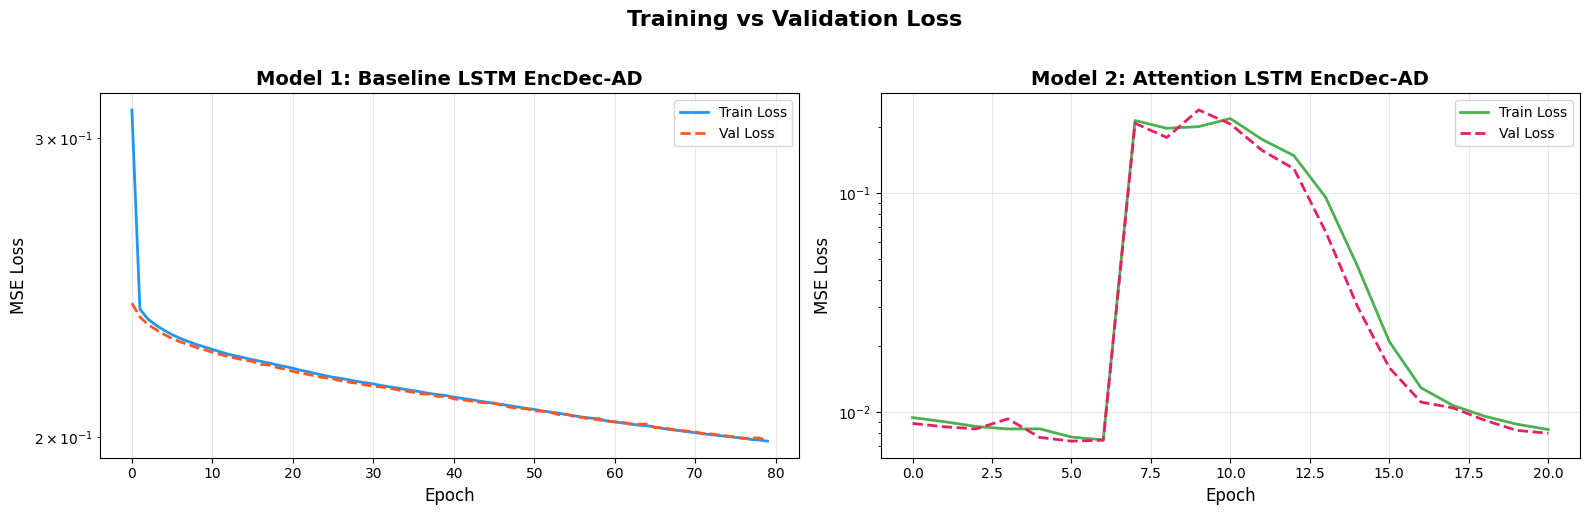

In [36]:
# ============================================================
# PLOT TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Baseline
ax1 = axes[0]
ax1.plot(baseline_history.history['loss'], label='Train Loss', linewidth=2, color='#2196F3')
ax1.plot(baseline_history.history['val_loss'], label='Val Loss', linewidth=2,
         linestyle='--', color='#FF5722')
ax1.set_title('Model 1: Baseline LSTM EncDec-AD', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()
ax1.set_yscale('log')

# Attention
ax2 = axes[1]
ax2.plot(attention_history.history['loss'], label='Train Loss', linewidth=2, color='#4CAF50')
ax2.plot(attention_history.history['val_loss'], label='Val Loss', linewidth=2,
         linestyle='--', color='#E91E63')
ax2.set_title('Model 2: Attention LSTM EncDec-AD', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.legend()
ax2.set_yscale('log')

plt.suptitle('Training vs Validation Loss', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 8. Reconstruction Error

For each timestep in a sequence, the reconstruction error is computed as:

$$e^{(i)} = |x^{(i)} - \hat{x}^{(i)}|$$

where:
- $x^{(i)}$ is the original input at timestep $i$
- $\hat{x}^{(i)}$ is the reconstruction (reversed back to original order)

The error is a **vector** with the same dimensionality as the feature space.

In [37]:
# ============================================================
# COMPUTE RECONSTRUCTION ERRORS (per-timestep, per Malhotra §2.2)
# ============================================================
# Paper: e^(i) = |x^(i) - x'^(i)| for each timestep i.
# The Gaussian is fitted to individual timestep error vectors,
# NOT to window-averaged errors.

def compute_reconstruction_errors(model, X, batch_size=256):
    """
    Returns:
        errors_flat: (n_samples * timesteps, n_features) — per-timestep errors
                     used to fit the Gaussian (vN2) and compute anomaly scores
        errors_3d:   (n_samples, timesteps, n_features)  — full error tensor
    """
    X_hat_reversed = model.predict(X, batch_size=batch_size, verbose=0)
    X_hat = X_hat_reversed[:, ::-1, :]          # un-reverse decoder output
    errors_3d = np.abs(X - X_hat)               # e^(i) = |x^(i) - x'^(i)|
    errors_flat = errors_3d.reshape(-1, X.shape[2])   # (N*L, m)
    return errors_3d, errors_flat

# --- Baseline ---
print('Computing reconstruction errors for BASELINE model...')
baseline_err3d_vN1,  baseline_err_vN1  = compute_reconstruction_errors(baseline_model, X_val_normal)
baseline_err3d_vN2,  baseline_err_vN2  = compute_reconstruction_errors(baseline_model, X_val_gauss)
baseline_err3d_vA,   baseline_err_vA   = compute_reconstruction_errors(baseline_model, X_vA)
baseline_err3d_test, baseline_err_test = compute_reconstruction_errors(baseline_model, X_test)

# --- Attention ---
print('Computing reconstruction errors for ATTENTION model...')
attention_err3d_vN1,  attention_err_vN1  = compute_reconstruction_errors(attention_model, X_val_normal)
attention_err3d_vN2,  attention_err_vN2  = compute_reconstruction_errors(attention_model, X_val_gauss)
attention_err3d_vA,   attention_err_vA   = compute_reconstruction_errors(attention_model, X_vA)
attention_err3d_test, attention_err_test = compute_reconstruction_errors(attention_model, X_test)

print(f'\nPer-timestep error shapes (used for Gaussian):')
print(f'  Baseline  vN2 (normal):    {baseline_err_vN2.shape}')
print(f'  Baseline  vA (anomalous):  {baseline_err_vA.shape}')
print(f'  Baseline  test:            {baseline_err_test.shape}')

Computing reconstruction errors for BASELINE model...
Computing reconstruction errors for ATTENTION model...

Per-timestep error shapes (used for Gaussian):
  Baseline  vN2 (normal):    (22890, 11)
  Baseline  vA (anomalous):  (36000, 11)
  Baseline  test:            (88320, 11)


---

## 9. Gaussian Modeling of Errors

Following the paper, we fit a **multivariate Gaussian distribution** to the reconstruction error vectors from the **normal validation data**.

- Compute the **mean vector** $\mu$ and **covariance matrix** $\Sigma$ from normal validation errors
- The anomaly score for a new error vector $e^{(i)}$ is the **Mahalanobis distance**:

$$a^{(i)} = (e^{(i)} - \mu)^T \Sigma^{-1} (e^{(i)} - \mu)$$

This accounts for the **correlation structure** between features — an error that is high in one feature might be normal if that feature has high variance, but alarming if it's typically stable.

In [38]:
# ============================================================
# FIT MULTIVARIATE GAUSSIAN & COMPUTE ANOMALY SCORES
# Per Malhotra et al. §2.2:
#   • Fit N(μ, Σ) on vN2 per-timestep error vectors via MLE
#   • a^(i) = (e^(i) − μ)^T Σ^{-1} (e^(i) − μ)   [Mahalanobis]
#   • Anomaly score for a sequence = max a^(i) over its L timesteps
# ============================================================

def fit_gaussian(error_flat):
    """Fit multivariate Gaussian on (N*L, m) per-timestep errors."""
    mu    = np.mean(error_flat, axis=0)
    sigma = np.cov(error_flat, rowvar=False) + np.eye(error_flat.shape[1]) * 1e-5
    sigma_inv = np.linalg.inv(sigma)
    return mu, sigma, sigma_inv

def compute_anomaly_scores(errors_3d, mu, sigma_inv):
    """
    Args:
        errors_3d: (n_samples, L, m) — per-timestep absolute errors
    Returns:
        scores: (n_samples,) — max Mahalanobis distance over L timesteps
    """
    n, L, m = errors_3d.shape
    diff = errors_3d.reshape(n * L, m) - mu          # (N*L, m)
    # Mahalanobis squared per timestep
    maha = np.sum(diff @ sigma_inv * diff, axis=1)    # (N*L,)
    maha = maha.reshape(n, L)                          # (N, L)
    return maha.max(axis=1)                            # (N,) — max over timesteps

# --- Baseline ---
print('Fitting Gaussian for BASELINE model (on vN2 per-timestep errors)...')
baseline_mu, baseline_sigma, baseline_sigma_inv = fit_gaussian(baseline_err_vN2)

# Validation scores (vN2 normal + vA anomalous)
baseline_err3d_vN2_full, _ = compute_reconstruction_errors(baseline_model, X_vN2)
baseline_err3d_vA_full,  _ = compute_reconstruction_errors(baseline_model, X_vA)
baseline_scores_val = np.concatenate([
    compute_anomaly_scores(baseline_err3d_vN2_full, baseline_mu, baseline_sigma_inv),
    compute_anomaly_scores(baseline_err3d_vA_full,  baseline_mu, baseline_sigma_inv)
])
baseline_scores_test = compute_anomaly_scores(baseline_err3d_test, baseline_mu, baseline_sigma_inv)

# --- Attention ---
print('Fitting Gaussian for ATTENTION model (on vN2 per-timestep errors)...')
attention_mu, attention_sigma, attention_sigma_inv = fit_gaussian(attention_err_vN2)

attention_err3d_vN2_full, _ = compute_reconstruction_errors(attention_model, X_vN2)
attention_err3d_vA_full,  _ = compute_reconstruction_errors(attention_model, X_vA)
attention_scores_val = np.concatenate([
    compute_anomaly_scores(attention_err3d_vN2_full, attention_mu, attention_sigma_inv),
    compute_anomaly_scores(attention_err3d_vA_full,  attention_mu, attention_sigma_inv)
])
attention_scores_test = compute_anomaly_scores(attention_err3d_test, attention_mu, attention_sigma_inv)

print(f'\nAnomaly score stats (Mahalanobis max-over-timesteps):')
print(f'  Baseline  — Val normal mean:    {baseline_scores_val[:len(X_vN2)].mean():.4f}')
print(f'  Baseline  — Val anomalous mean: {baseline_scores_val[len(X_vN2):].mean():.4f}')
print(f'  Attention — Val normal mean:    {attention_scores_val[:len(X_vN2)].mean():.4f}')
print(f'  Attention — Val anomalous mean: {attention_scores_val[len(X_vN2):].mean():.4f}')

Fitting Gaussian for BASELINE model (on vN2 per-timestep errors)...
Fitting Gaussian for ATTENTION model (on vN2 per-timestep errors)...

Anomaly score stats (Mahalanobis max-over-timesteps):
  Baseline  — Val normal mean:    27.6477
  Baseline  — Val anomalous mean: 609.9057
  Attention — Val normal mean:    58.9227
  Attention — Val anomalous mean: 4034.0819


---

## 10. Threshold Selection

We select the optimal threshold $\tau$ that maximizes the **F-beta score** on the combined validation set (normal + anomalous).

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

With $\beta = 0.5$, we **emphasize precision** over recall. This is appropriate because:
- False positives (unnecessary maintenance) are costly
- The paper notes that recall is naturally lower in this setting (since early degradation is hard to detect)

In [39]:
# ============================================================
# THRESHOLD OPTIMIZATION
# Per Malhotra et al. §2.2:
#   τ is chosen to maximise F_β on validation set (vN2 + vA).
#   For FD001 (single op condition, single fault mode), β=1.0 (F1)
#   is appropriate — cleaner data enables balanced precision & recall.
# ============================================================

def optimize_threshold(scores, labels, beta=BETA, n_thresholds=500):
    """
    Find threshold τ that maximises F_β on the combined validation set.

    Args:
        scores : (n_samples,)  — Mahalanobis anomaly scores
        labels : (n_samples,)  — 0 = normal, 1 = anomalous  (vN2 + vA)
        beta   : float         — β for F_β  (paper uses 0.05 for engines)
        n_thresholds : int     — candidate grid size

    Returns:
        best_threshold : float
        best_fbeta     : float
        threshold_results : dict of arrays at each candidate τ
    """
    thresholds = np.linspace(scores.min(), scores.max(), n_thresholds)

    precisions, recalls, fbetas = [], [], []

    for tau in thresholds:
        preds = (scores > tau).astype(int)

        tp = np.sum((preds == 1) & (labels == 1))
        fp = np.sum((preds == 1) & (labels == 0))
        fn = np.sum((preds == 0) & (labels == 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        fb = ((1 + beta**2) * precision * recall /
              (beta**2 * precision + recall)) if (precision + recall) > 0 else 0.0

        precisions.append(precision)
        recalls.append(recall)
        fbetas.append(fb)

    precisions = np.array(precisions)
    recalls    = np.array(recalls)
    fbetas     = np.array(fbetas)

    best_idx       = np.argmax(fbetas)
    best_threshold = thresholds[best_idx]
    best_fbeta     = fbetas[best_idx]

    threshold_results = {
        'thresholds': thresholds,
        'precisions': precisions,
        'recalls':    recalls,
        'fbetas':     fbetas,
        'best_idx':   best_idx,
    }

    return best_threshold, best_fbeta, threshold_results


# --- Baseline ---
print('Optimizing threshold for BASELINE model (on vN2 + vA)...')
baseline_threshold, baseline_best_fb, baseline_thresh_results = optimize_threshold(
    baseline_scores_val, y_val_thresh, beta=BETA          # ← y_val_thresh (vN2+vA)
)
print(f'  Best threshold τ : {baseline_threshold:.4f}')
print(f'  Best F-{BETA}        : {baseline_best_fb:.4f}')
print(f'  Precision        : {baseline_thresh_results["precisions"][baseline_thresh_results["best_idx"]]:.4f}')
print(f'  Recall           : {baseline_thresh_results["recalls"][baseline_thresh_results["best_idx"]]:.4f}')

print()

# --- Attention ---
print('Optimizing threshold for ATTENTION model (on vN2 + vA)...')
attention_threshold, attention_best_fb, attention_thresh_results = optimize_threshold(
    attention_scores_val, y_val_thresh, beta=BETA         # ← y_val_thresh (vN2+vA)
)
print(f'  Best threshold τ : {attention_threshold:.4f}')
print(f'  Best F-{BETA}        : {attention_best_fb:.4f}')
print(f'  Precision        : {attention_thresh_results["precisions"][attention_thresh_results["best_idx"]]:.4f}')
print(f'  Recall           : {attention_thresh_results["recalls"][attention_thresh_results["best_idx"]]:.4f}')

Optimizing threshold for BASELINE model (on vN2 + vA)...
  Best threshold τ : 32.3644
  Best F-1.0        : 0.8649
  Precision        : 0.8656
  Recall           : 0.8642

Optimizing threshold for ATTENTION model (on vN2 + vA)...
  Best threshold τ : 115.9241
  Best F-1.0        : 0.9537
  Precision        : 0.9387
  Recall           : 0.9692


---

## 11. Evaluation Metrics

We evaluate both models on the **test set** using the thresholds optimized on the validation set.

In [40]:
# ============================================================
# EVALUATION ON TEST SET  (tN + tA)
# ============================================================

def evaluate_model(scores, labels, threshold, beta=BETA, model_name='Model'):
    """
    Evaluate on the held-out test set (tN + tA).
    """
    predictions = (scores > threshold).astype(int)

    tp = np.sum((predictions == 1) & (labels == 1))
    fp = np.sum((predictions == 1) & (labels == 0))
    fn = np.sum((predictions == 0) & (labels == 1))
    tn = np.sum((predictions == 0) & (labels == 0))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fb        = ((1 + beta**2) * precision * recall /
                 (beta**2 * precision + recall)) if (precision + recall) > 0 else 0.0

    fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tpr_fpr   = recall / fpr if fpr > 0 else float('inf')

    cm = confusion_matrix(labels, predictions)

    print(f'\n{"="*52}')
    print(f'{model_name} — Test Set Evaluation')
    print(f'{"="*52}')
    print(f'  Threshold τ  : {threshold:.4f}')
    print(f'  Precision    : {precision:.4f}')
    print(f'  Recall (TPR) : {recall:.4f}')
    print(f'  F-{beta}     : {fb:.4f}')
    print(f'  FPR          : {fpr:.4f}')
    print(f'  TPR/FPR      : {tpr_fpr:.2f}')

    print(f'\n  Confusion Matrix:')
    print(f'                  Pred Normal  Pred Anomaly')
    print(f'  Actual Normal   {cm[0,0]:>10d}  {cm[0,1]:>12d}')
    print(f'  Actual Anomaly  {cm[1,0]:>10d}  {cm[1,1]:>12d}')

    return {
        'precision': precision,
        'recall': recall,
        'fbeta': fb,
        'fpr': fpr,
        'tpr_fpr': tpr_fpr,
        'confusion_matrix': cm,
        'predictions': predictions
    }


# ------------------------------------------------------------
# Run Evaluation
# ------------------------------------------------------------

baseline_metrics = evaluate_model(
    baseline_scores_test, y_test, baseline_threshold,
    beta=BETA, model_name='Baseline LSTM EncDec-AD'
)

attention_metrics = evaluate_model(
    attention_scores_test, y_test, attention_threshold,
    beta=BETA, model_name='Attention LSTM EncDec-AD'
)


Baseline LSTM EncDec-AD — Test Set Evaluation
  Threshold τ  : 32.3644
  Precision    : 0.8840
  Recall (TPR) : 0.8972
  F-1.0     : 0.8905
  FPR          : 0.1853
  TPR/FPR      : 4.84

  Confusion Matrix:
                  Pred Normal  Pred Anomaly
  Actual Normal          932           212
  Actual Anomaly         185          1615

Attention LSTM EncDec-AD — Test Set Evaluation
  Threshold τ  : 115.9241
  Precision    : 0.9377
  Recall (TPR) : 0.9700
  F-1.0     : 0.9536
  FPR          : 0.1014
  TPR/FPR      : 9.57

  Confusion Matrix:
                  Pred Normal  Pred Anomaly
  Actual Normal         1028           116
  Actual Anomaly          54          1746


---

## 12. Visualization

Comprehensive visualizations of the anomaly detection pipeline.

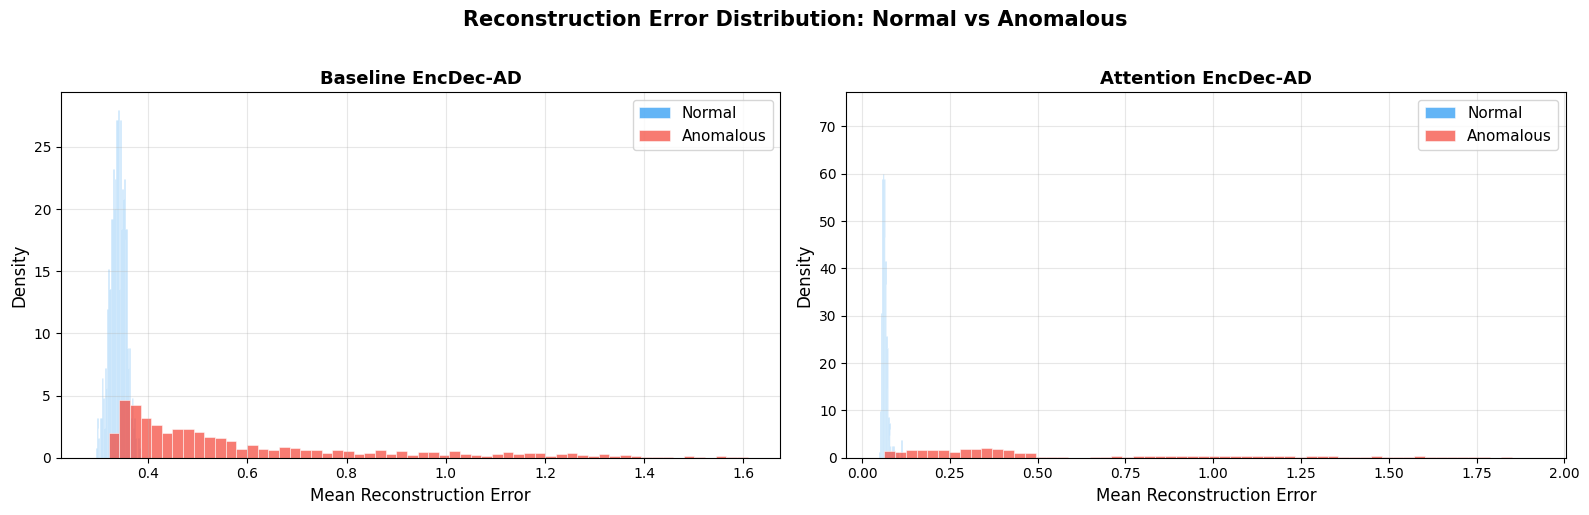

In [41]:
# ============================================================
# VISUALIZATION 1: Reconstruction Error Distribution
# ============================================================

# Derive per-sample mean error arrays from already-computed 3D errors
# Normal: use vN2 errors; Anomalous: use vA errors
baseline_err_val_n = baseline_err3d_vN2.mean(axis=1)   # (n_vN2, n_features)
baseline_err_val_a = baseline_err3d_vA.mean(axis=1)    # (n_vA, n_features)
attention_err_val_n = attention_err3d_vN2.mean(axis=1)
attention_err_val_a = attention_err3d_vA.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, err_n, err_a, title in zip(
    axes,
    [baseline_err_val_n.mean(axis=1), attention_err_val_n.mean(axis=1)],
    [baseline_err_val_a.mean(axis=1), attention_err_val_a.mean(axis=1)],
    ['Baseline EncDec-AD', 'Attention EncDec-AD']
):
    ax.hist(err_n, bins=60, alpha=0.7, label='Normal', color='#2196F3',
            density=True, edgecolor='white', linewidth=0.5)
    ax.hist(err_a, bins=60, alpha=0.7, label='Anomalous', color='#F44336',
            density=True, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean Reconstruction Error')
    ax.set_ylabel('Density')
    ax.legend(fontsize=11)

plt.suptitle('Reconstruction Error Distribution: Normal vs Anomalous',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


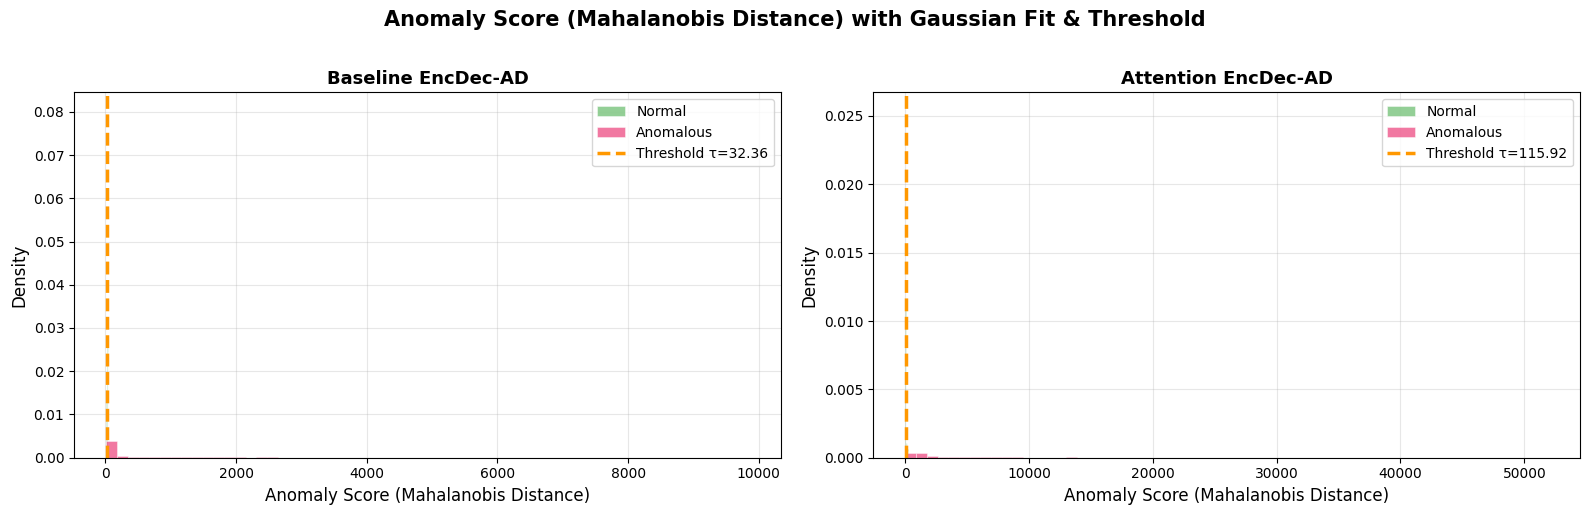

In [42]:
# ============================================================
# VISUALIZATION 2: Anomaly Score Distribution (Mahalanobis)
# ============================================================

# y_val_thresh is already defined: 0=normal (vN2), 1=anomalous (vA)
y_val_combined = y_val_thresh  # alias for clarity in plots

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, scores, labels, threshold, title in zip(
    axes,
    [baseline_scores_val, attention_scores_val],
    [y_val_combined, y_val_combined],
    [baseline_threshold, attention_threshold],
    ['Baseline EncDec-AD', 'Attention EncDec-AD']
):
    normal_scores = scores[labels == 0]
    anomalous_scores = scores[labels == 1]
    
    ax.hist(normal_scores, bins=60, alpha=0.6, label='Normal', color='#4CAF50',
            density=True, edgecolor='white', linewidth=0.5)
    ax.hist(anomalous_scores, bins=60, alpha=0.6, label='Anomalous', color='#E91E63',
            density=True, edgecolor='white', linewidth=0.5)
    ax.axvline(x=threshold, color='#FF9800', linestyle='--', linewidth=2.5,
               label=f'Threshold \u03c4={threshold:.2f}')
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Anomaly Score (Mahalanobis Distance)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=10)

plt.suptitle('Anomaly Score (Mahalanobis Distance) with Gaussian Fit & Threshold',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


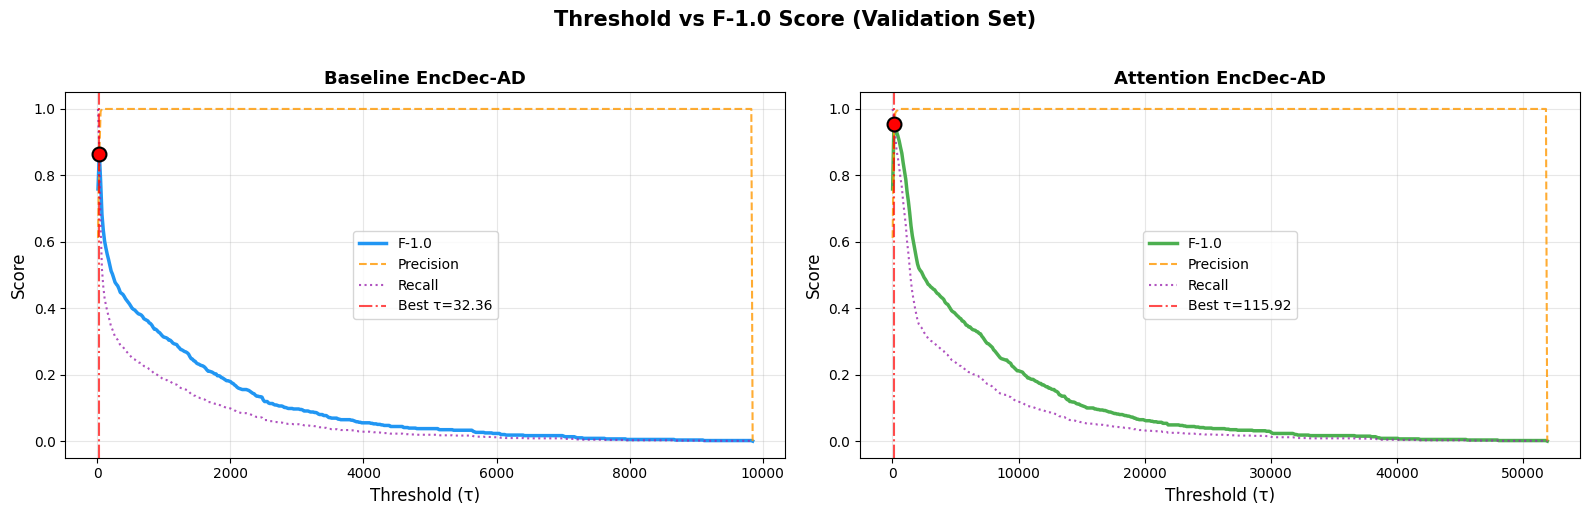

In [43]:
# ============================================================
# VISUALIZATION 3: Threshold vs F-beta Curve
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, results, threshold, fb, title, color in zip(
    axes,
    [baseline_thresh_results, attention_thresh_results],
    [baseline_threshold, attention_threshold],
    [baseline_best_fb, attention_best_fb],
    ['Baseline EncDec-AD', 'Attention EncDec-AD'],
    ['#2196F3', '#4CAF50']
):
    thresholds = results['thresholds']
    
    ax.plot(thresholds, results['fbetas'], linewidth=2.5, color=color,
            label=f'F-{BETA}')
    ax.plot(thresholds, results['precisions'], linewidth=1.5, linestyle='--',
            color='#FF9800', alpha=0.8, label='Precision')
    ax.plot(thresholds, results['recalls'], linewidth=1.5, linestyle=':',
            color='#9C27B0', alpha=0.8, label='Recall')
    ax.axvline(x=threshold, color='red', linestyle='-.', linewidth=1.5,
               alpha=0.7, label=f'Best τ={threshold:.2f}')
    ax.scatter([threshold], [fb], color='red', s=100, zorder=5,
               edgecolors='black', linewidths=1.5)
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Threshold (τ)')
    ax.set_ylabel('Score')
    ax.legend(fontsize=10)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle(f'Threshold vs F-{BETA} Score (Validation Set)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

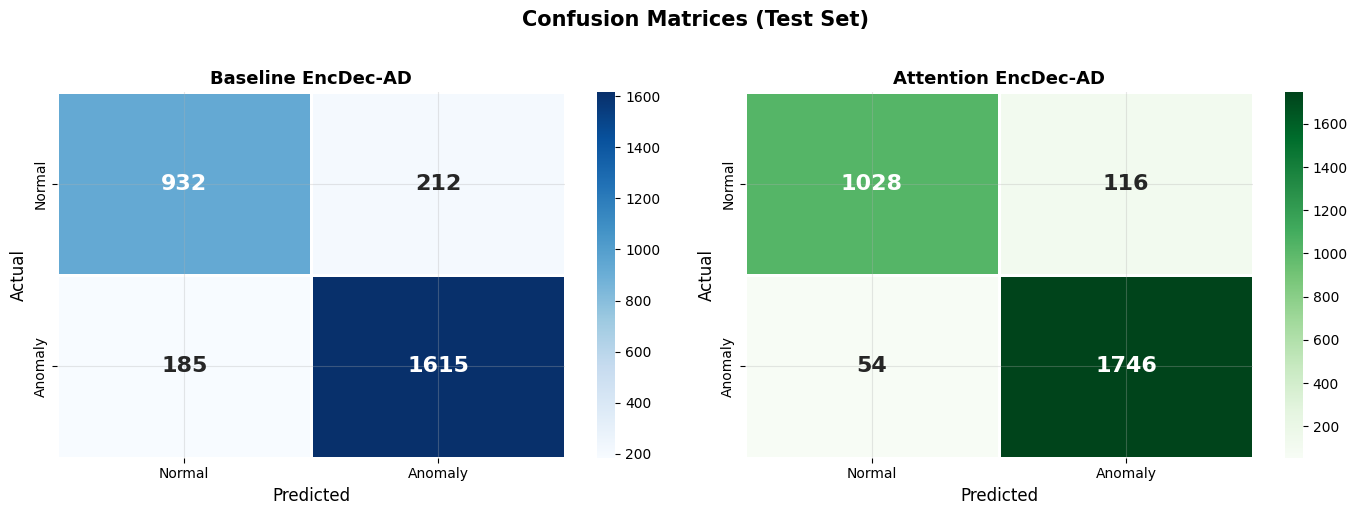

In [44]:
# ============================================================
# VISUALIZATION 4: Confusion Matrices
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metrics, title, cmap in zip(
    axes,
    [baseline_metrics, attention_metrics],
    ['Baseline EncDec-AD', 'Attention EncDec-AD'],
    ['Blues', 'Greens']
):
    cm = metrics['confusion_matrix']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap, ax=ax,
        xticklabels=['Normal', 'Anomaly'],
        yticklabels=['Normal', 'Anomaly'],
        annot_kws={'size': 16, 'fontweight': 'bold'},
        linewidths=2, linecolor='white'
    )
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle('Confusion Matrices (Test Set)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

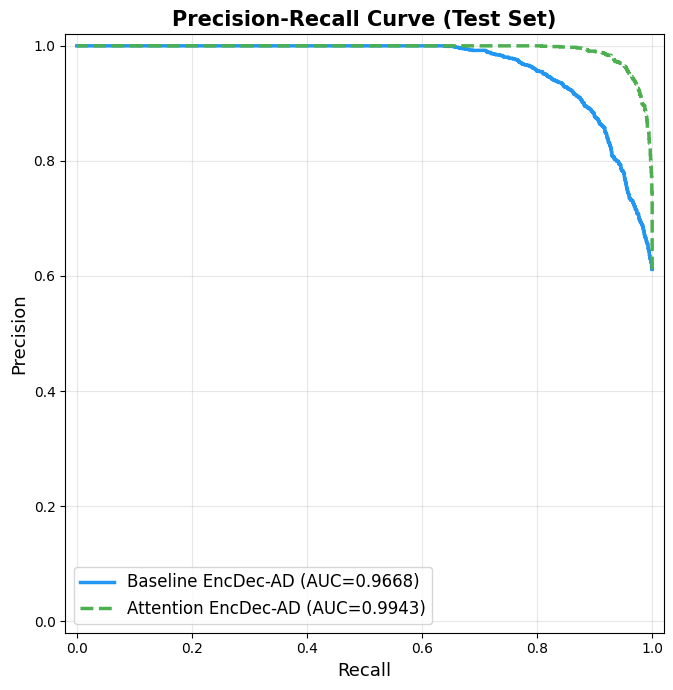

In [45]:
# ============================================================
# VISUALIZATION 5: Precision-Recall Curve
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

for scores, labels, title, color, ls in zip(
    [baseline_scores_test, attention_scores_test],
    [y_test, y_test],
    ['Baseline EncDec-AD', 'Attention EncDec-AD'],
    ['#2196F3', '#4CAF50'],
    ['-', '--']
):
    precision_curve, recall_curve, _ = precision_recall_curve(labels, scores)
    pr_auc = auc(recall_curve, precision_curve)
    ax.plot(recall_curve, precision_curve, linewidth=2.5, color=color, linestyle=ls,
            label=f'{title} (AUC={pr_auc:.4f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve (Test Set)', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower left')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


--- Engine Unit 1 ---


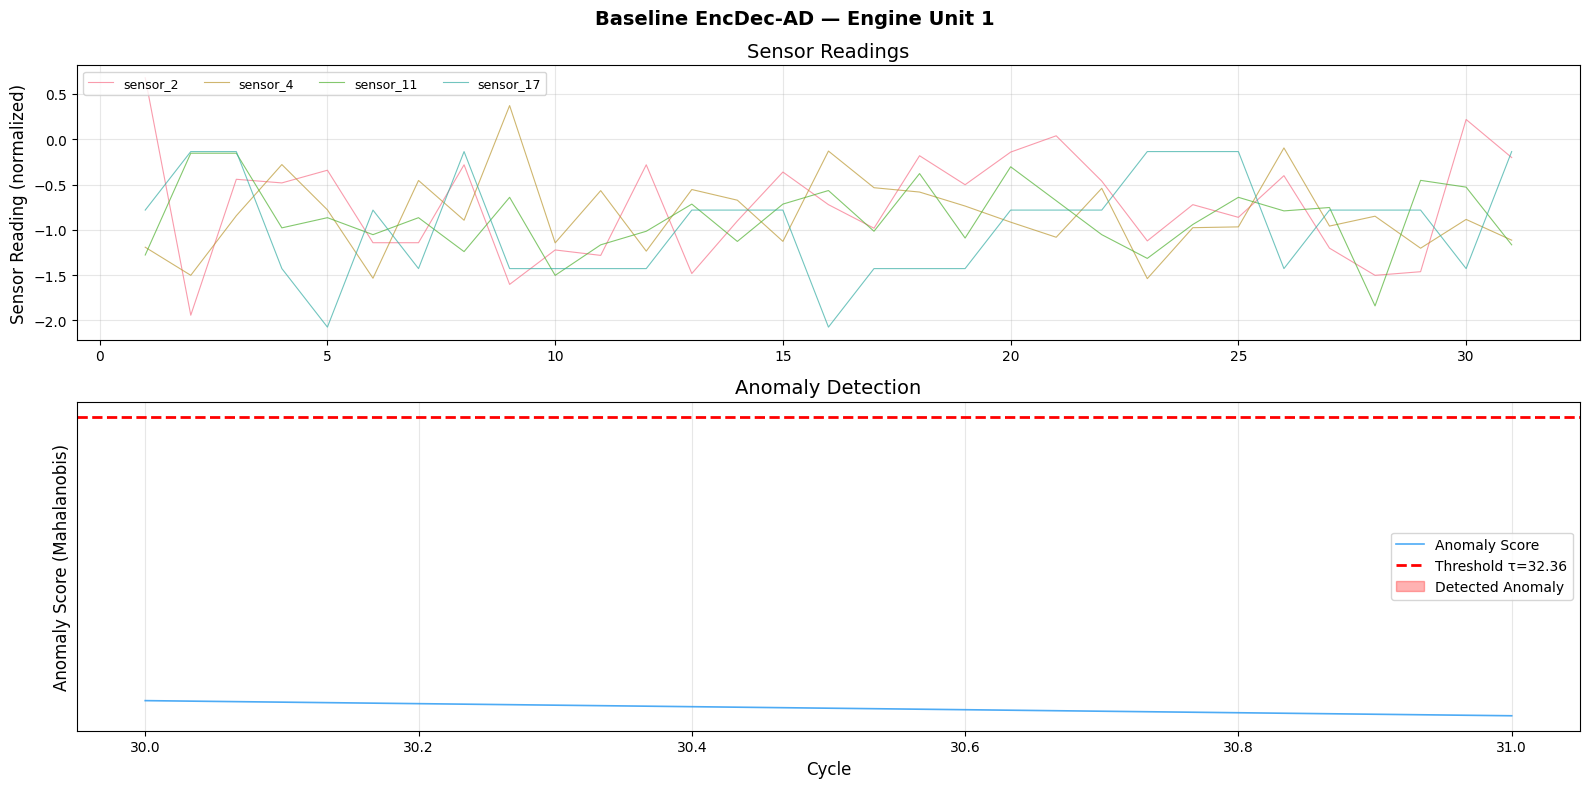

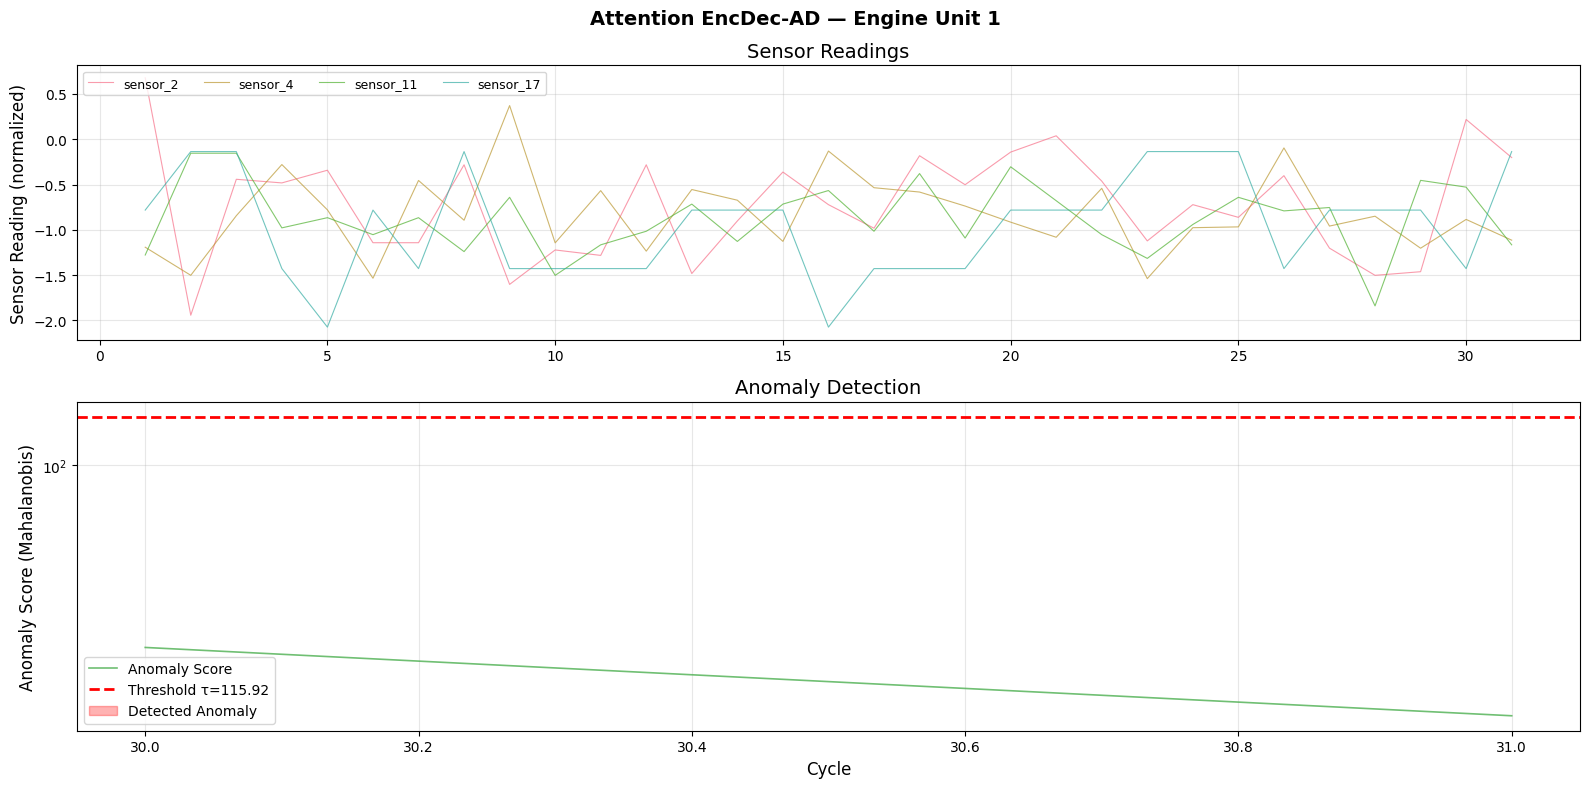


--- Engine Unit 2 ---


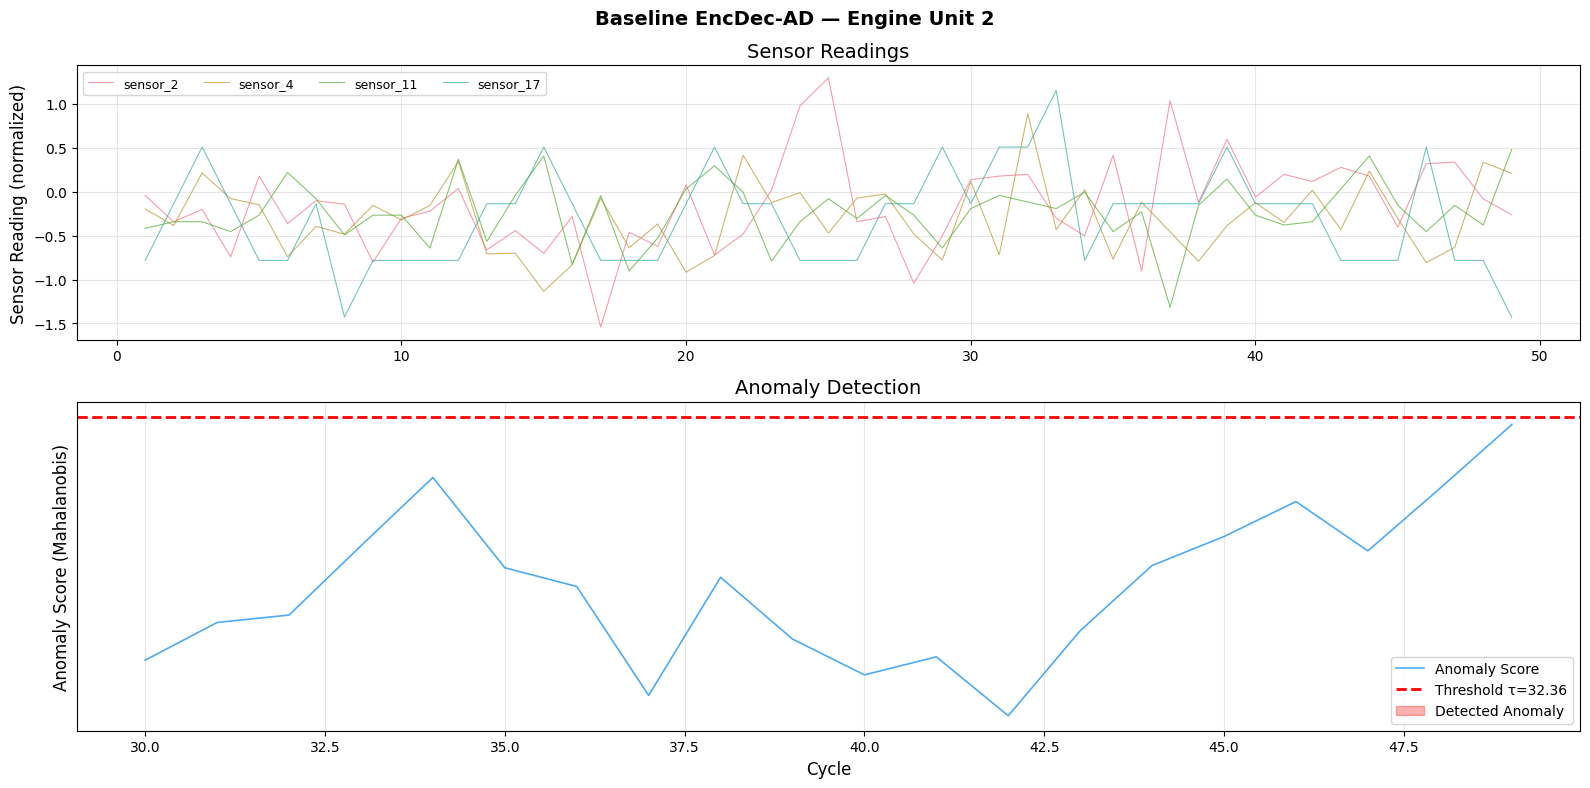

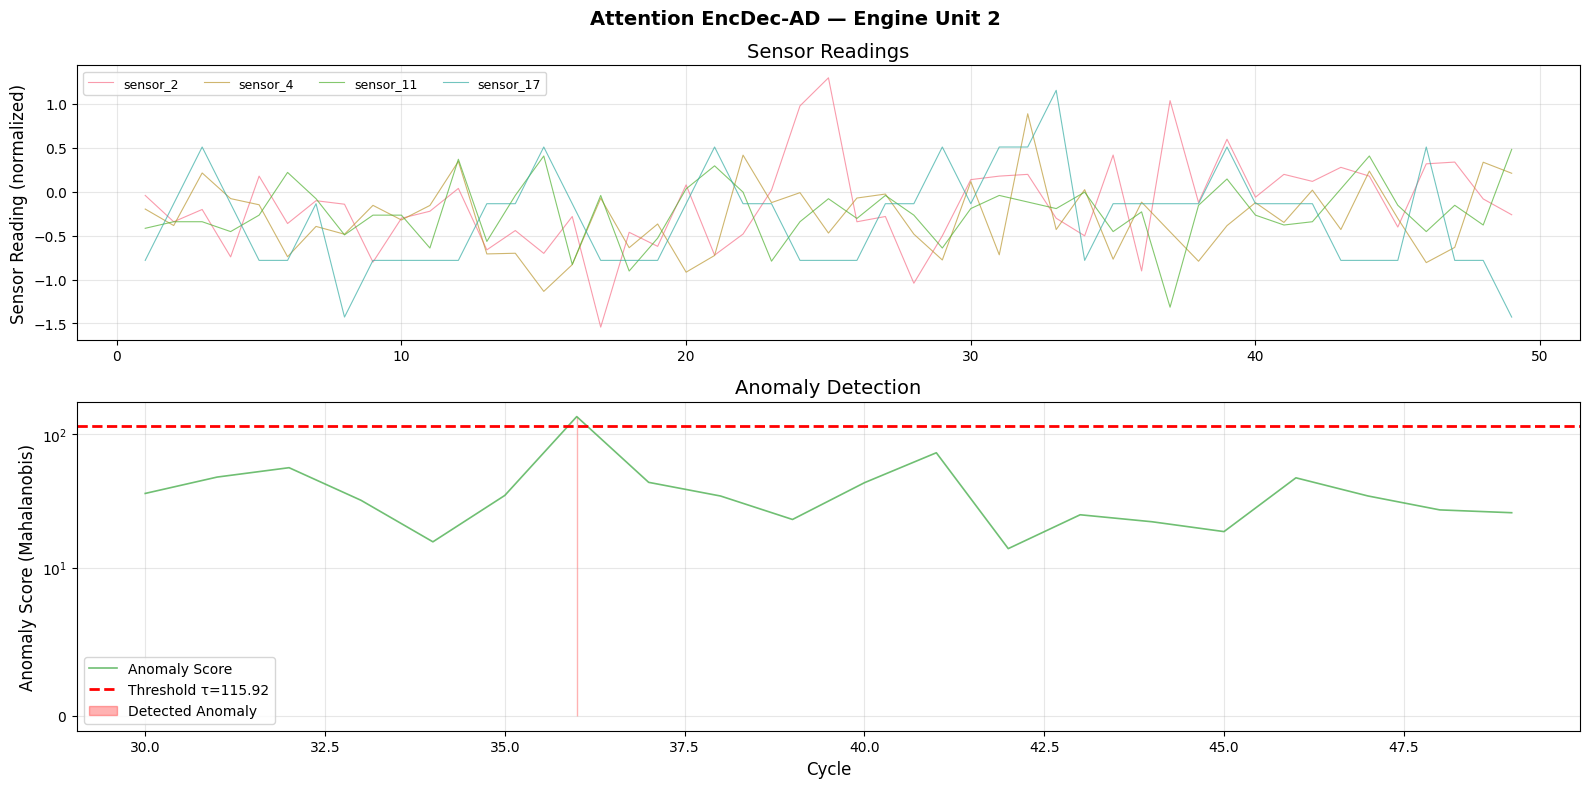


--- Engine Unit 3 ---


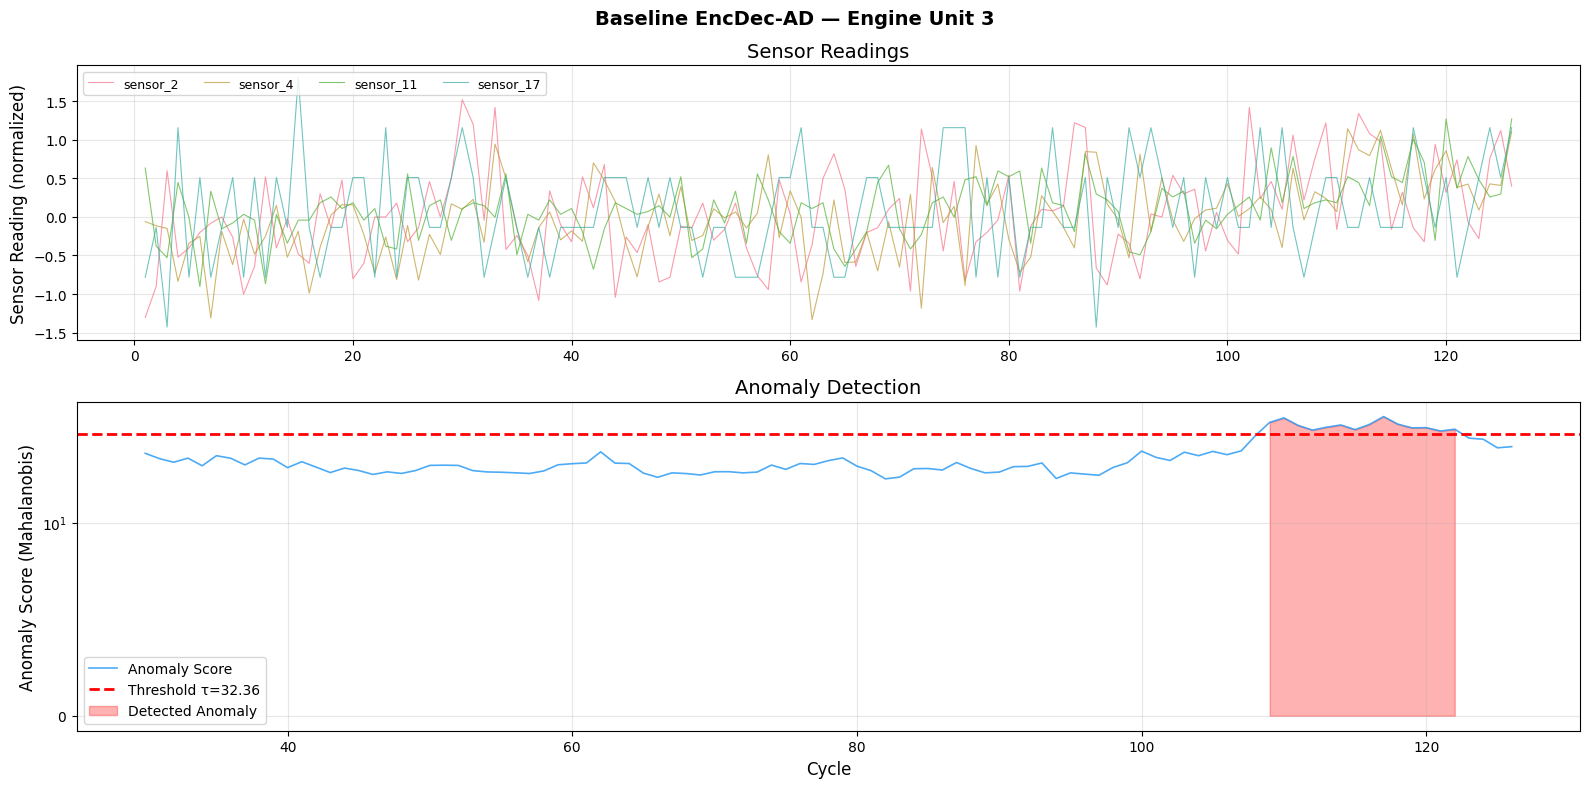

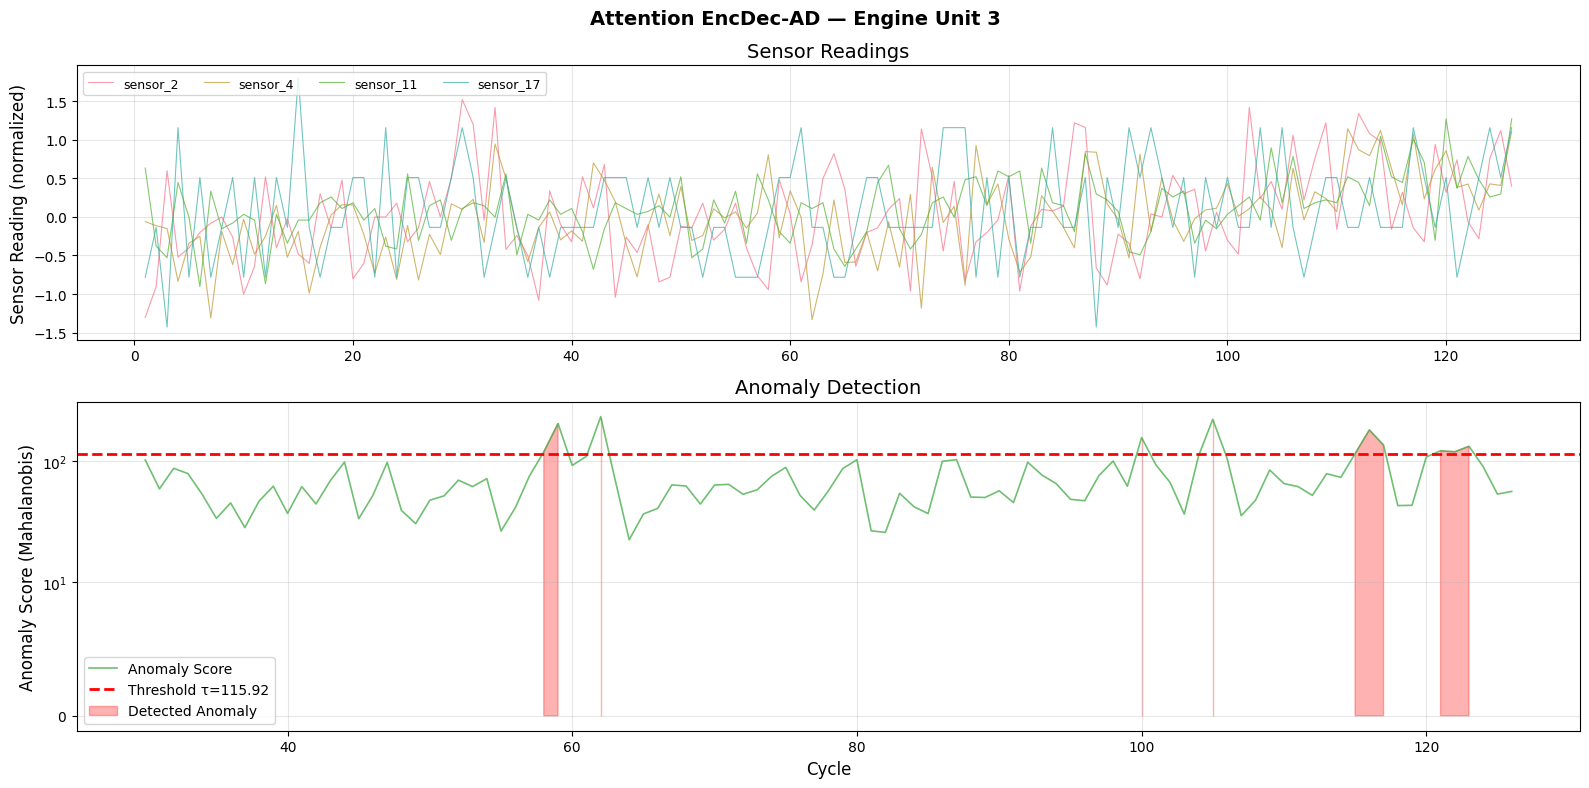

In [46]:
# ============================================================
# VISUALIZATION 6: Time-Series with Anomaly Scores (FIXED)
# ============================================================

def plot_engine_anomaly_scores(model, model_name, mu, sigma_inv, threshold,
                                df, feature_cols, window_size, unit_id, color):
    """
    Plot sensor readings and anomaly scores over time for a single engine.
    """
    unit_data = df[df['unit_id'] == unit_id][feature_cols].values
    unit_rul = df[df['unit_id'] == unit_id]['RUL'].values
    n_cycles = len(unit_data)
    
    if n_cycles < window_size:
        print(f'Unit {unit_id} has fewer than {window_size} cycles. Skipping.')
        return
    
    # Create windows for this engine
    windows = []
    for i in range(n_cycles - window_size + 1):
        windows.append(unit_data[i:i + window_size])
    windows = np.array(windows)
    
    # FIX: correct unpacking order
    errors_per_window, _ = compute_reconstruction_errors(model, windows)
    
    # Compute anomaly scores
    scores = compute_anomaly_scores(errors_per_window, mu, sigma_inv)
    
    # Time axis for scores (aligned to window end)
    cycles = np.arange(window_size, n_cycles + 1)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), height_ratios=[1, 1.2])
    fig.suptitle(f'{model_name} — Engine Unit {unit_id}',
                 fontsize=14, fontweight='bold')
    
    # Top: Selected sensor readings
    for i, sensor_idx in enumerate([0, 2, 5, 8]):
        if sensor_idx < len(feature_cols):
            ax1.plot(range(1, n_cycles + 1), unit_data[:, sensor_idx],
                     linewidth=0.8, alpha=0.7, label=feature_cols[sensor_idx])
    ax1.set_ylabel('Sensor Reading (normalized)')
    ax1.legend(fontsize=9, ncol=4, loc='upper left')
    ax1.set_title('Sensor Readings')
    
    # Bottom: Anomaly scores
    ax2.plot(cycles, scores, linewidth=1.2, color=color, alpha=0.8, label='Anomaly Score')
    ax2.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
                label=f'Threshold τ={threshold:.2f}')
    ax2.fill_between(cycles, 0, scores,
                     where=scores > threshold,
                     color='red', alpha=0.3, label='Detected Anomaly')
    ax2.set_xlabel('Cycle')
    ax2.set_ylabel('Anomaly Score (Mahalanobis)')
    ax2.set_title('Anomaly Detection')
    ax2.legend(fontsize=10)
    ax2.set_yscale('symlog', linthresh=10)
    
    plt.tight_layout()
    plt.show()


# Plot for a few test engines
sample_test_units = test_df['unit_id'].unique()[:3]

for unit_id in sample_test_units:
    print(f'\n--- Engine Unit {unit_id} ---')
    
    plot_engine_anomaly_scores(
        baseline_model, 'Baseline EncDec-AD',
        baseline_mu, baseline_sigma_inv, baseline_threshold,
        test_df, FEATURE_COLS, WINDOW_SIZE, unit_id, '#2196F3'
    )
    
    plot_engine_anomaly_scores(
        attention_model, 'Attention EncDec-AD',
        attention_mu, attention_sigma_inv, attention_threshold,
        test_df, FEATURE_COLS, WINDOW_SIZE, unit_id, '#4CAF50'
    )

---

## 13. Model Comparison

### Baseline vs Attention-based LSTM Encoder-Decoder

In [47]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

comparison_data = {
    'Metric': ['Precision', 'Recall', f'F-{BETA} Score', 'Threshold (τ)',
               'Model Parameters', 'Training Epochs'],
    'Baseline EncDec-AD': [
        f"{baseline_metrics['precision']:.4f}",
        f"{baseline_metrics['recall']:.4f}",
        f"{baseline_metrics['fbeta']:.4f}",
        f"{baseline_threshold:.4f}",
        f"{baseline_model.count_params():,}",
        f"{len(baseline_history.history['loss'])}"
    ],
    'Attention EncDec-AD': [
        f"{attention_metrics['precision']:.4f}",
        f"{attention_metrics['recall']:.4f}",
        f"{attention_metrics['fbeta']:.4f}",
        f"{attention_threshold:.4f}",
        f"{attention_model.count_params():,}",
        f"{len(attention_history.history['loss'])}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print('\n' + '='*70)
print('MODEL COMPARISON — Test Set Results')
print('='*70)
print(comparison_df.to_string(index=False))
print('='*70)


MODEL COMPARISON — Test Set Results
          Metric Baseline EncDec-AD Attention EncDec-AD
       Precision             0.8840              0.9377
          Recall             0.8972              0.9700
     F-1.0 Score             0.8905              0.9536
   Threshold (τ)            32.3644            115.9241
Model Parameters             53,195              58,027
 Training Epochs                 80                  21


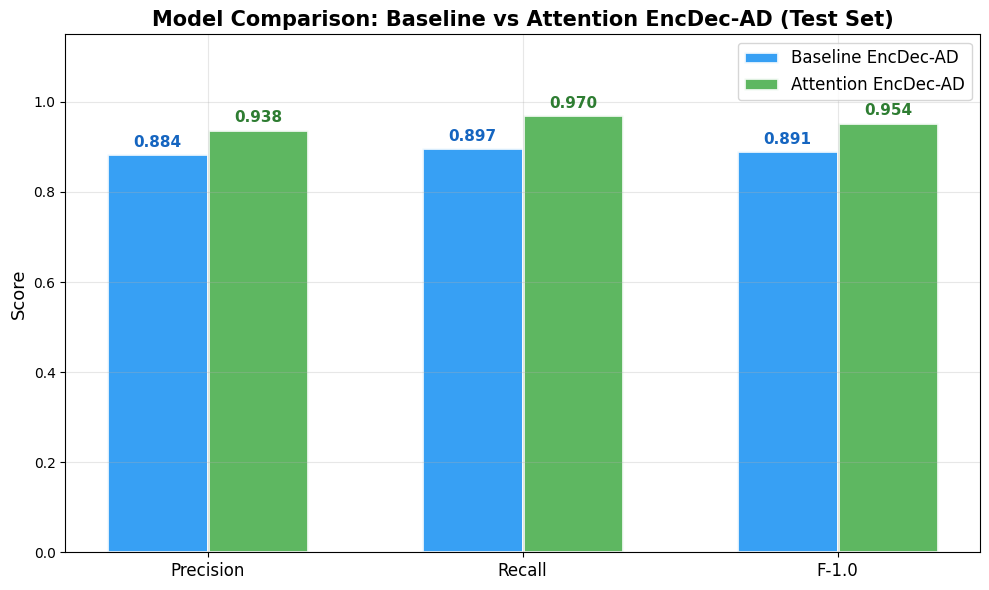

In [48]:
# ============================================================
# MODEL COMPARISON GRAPH
# ============================================================

metrics_names = ['Precision', 'Recall', f'F-{BETA}']
baseline_vals = [
    baseline_metrics['precision'],
    baseline_metrics['recall'],
    baseline_metrics['fbeta']
]
attention_vals = [
    attention_metrics['precision'],
    attention_metrics['recall'],
    attention_metrics['fbeta']
]

x = np.arange(len(metrics_names))
bar_width = 0.32

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - bar_width/2, baseline_vals, bar_width,
               label='Baseline EncDec-AD', color='#2196F3',
               edgecolor='white', linewidth=2, alpha=0.9)
bars2 = ax.bar(x + bar_width/2, attention_vals, bar_width,
               label='Attention EncDec-AD', color='#4CAF50',
               edgecolor='white', linewidth=2, alpha=0.9)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#1565C0')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#2E7D32')

ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Comparison: Baseline vs Attention EncDec-AD (Test Set)',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

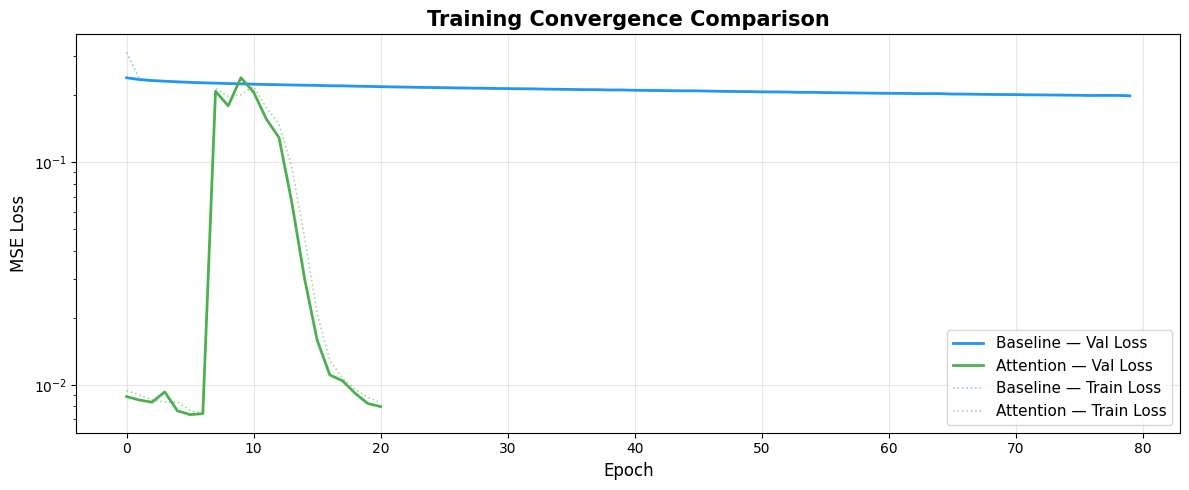

In [49]:
# ============================================================
# COMBINED TRAINING LOSS COMPARISON
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(baseline_history.history['val_loss'], linewidth=2, color='#2196F3',
        label='Baseline — Val Loss')
ax.plot(attention_history.history['val_loss'], linewidth=2, color='#4CAF50',
        label='Attention — Val Loss')
ax.plot(baseline_history.history['loss'], linewidth=1.2, color='#2196F3',
        linestyle=':', alpha=0.5, label='Baseline — Train Loss')
ax.plot(attention_history.history['loss'], linewidth=1.2, color='#4CAF50',
        linestyle=':', alpha=0.5, label='Attention — Train Loss')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training Convergence Comparison', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Analysis: Where Attention Helps

**Advantages of Attention:**
1. **Better long-range reconstruction**: By attending to all encoder states, the decoder can leverage information from any part of the input sequence, not just what's compressed into the final hidden state
2. **Sharper anomaly boundaries**: Attention enables more precise reconstruction, leading to a cleaner separation between normal and anomalous reconstruction errors
3. **Interpretability**: Attention weights reveal which input timesteps the decoder focuses on when reconstructing each output timestep

**Trade-offs (Complexity vs Performance):**
1. **Parameters**: The attention model has additional weight matrices (W₁, W₂, V) and the concatenation doubles the decoder output dimension, increasing total parameters
2. **Computation**: Computing attention at every decoder step adds O(T² · d) computation, where T is the sequence length and d is the hidden dimension
3. **Training time**: The attention model typically requires more time per epoch
4. **Marginal gains**: For settings where the sequence length is short (e.g., window_size=30), the information bottleneck is less severe, so attention may offer only modest improvements
5. **Overfitting risk**: Additional parameters may lead to overfitting on smaller datasets, though early stopping mitigates this

---

## 14. Gaussian Fit Visualization

Visualizing the fitted Gaussian on selected feature dimensions of the reconstruction error.

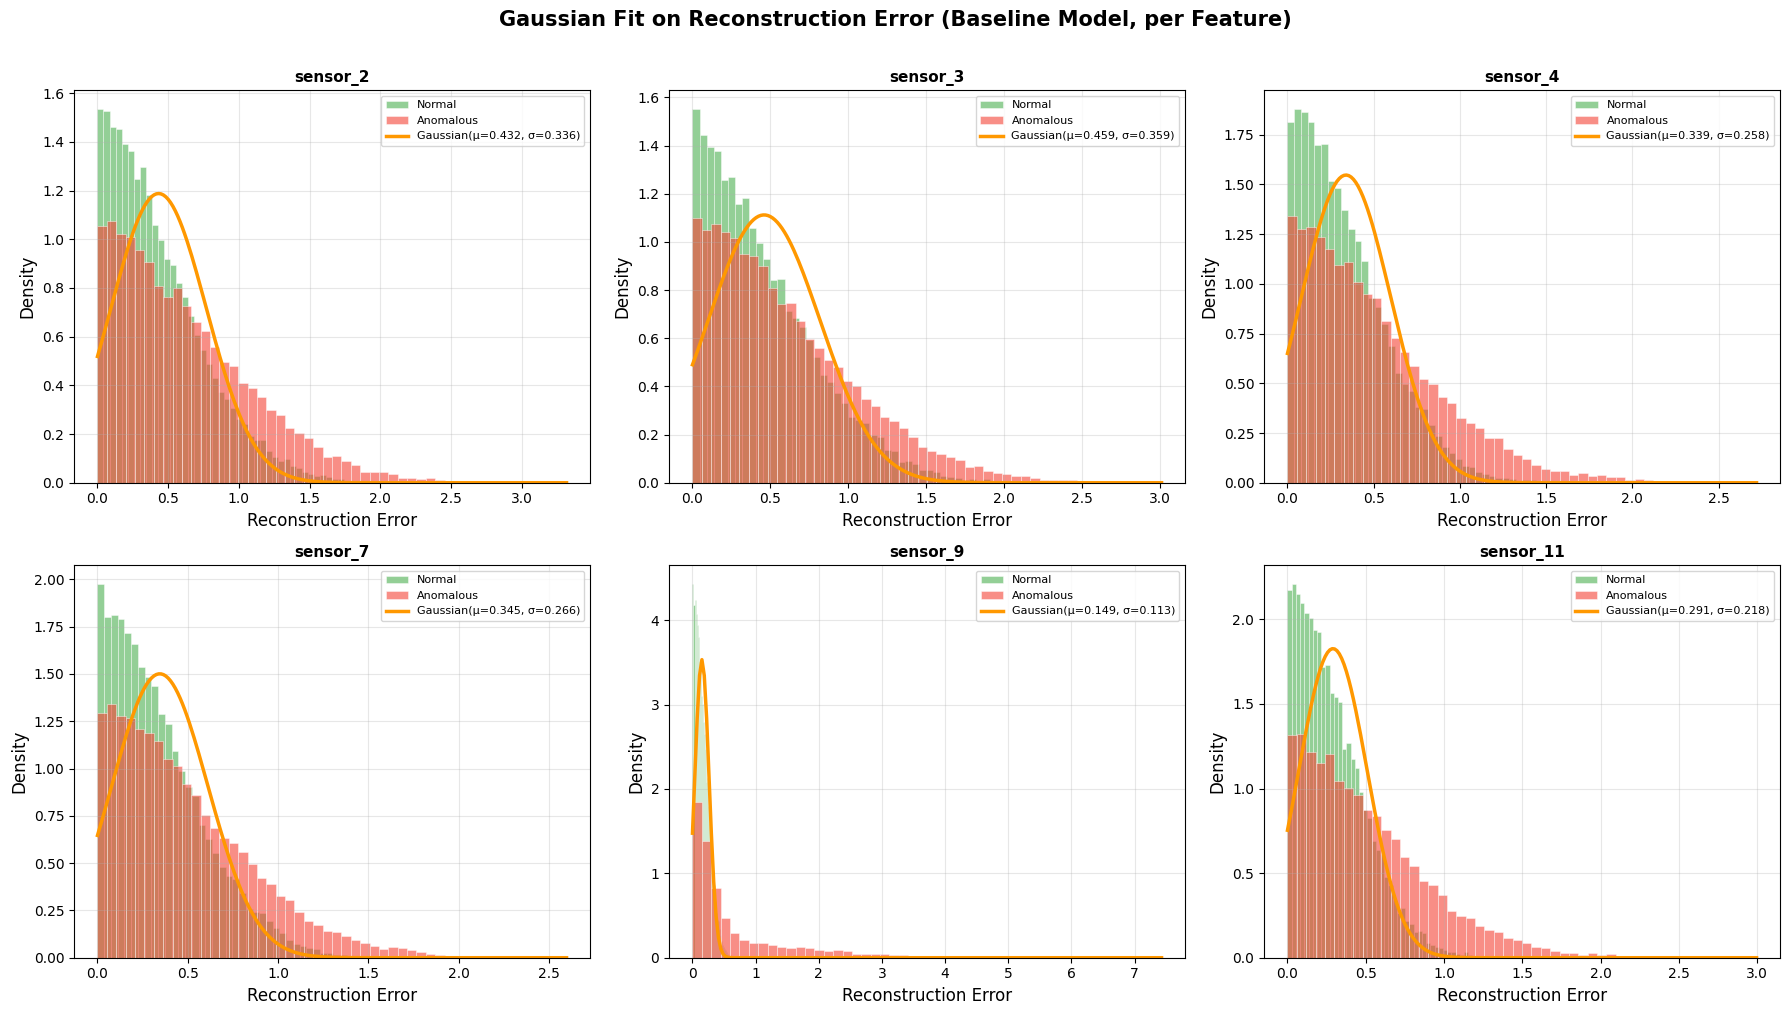

In [50]:
# ============================================================
# GAUSSIAN FIT VISUALIZATION (Baseline model)
# ============================================================

# Plot Gaussian fit for a few feature error dimensions
n_plot_features = min(6, n_features)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx in range(n_plot_features):
    ax = axes[idx]
    feature_name = FEATURE_COLS[idx]
    
    # Per-timestep errors for this feature (from vN2 normal and vA anomalous)
    normal_errs    = baseline_err3d_vN2.reshape(-1, n_features)[:, idx]
    anomalous_errs = baseline_err3d_vA.reshape(-1, n_features)[:, idx]
    
    # Plot histograms
    ax.hist(normal_errs, bins=50, alpha=0.6, density=True, color='#4CAF50',
            label='Normal', edgecolor='white', linewidth=0.5)
    ax.hist(anomalous_errs, bins=50, alpha=0.6, density=True, color='#F44336',
            label='Anomalous', edgecolor='white', linewidth=0.5)
    
    # Plot fitted Gaussian (marginal for this feature)
    mu_feat    = baseline_mu[idx]
    sigma_feat = np.sqrt(baseline_sigma[idx, idx])
    x_range = np.linspace(normal_errs.min(),
                          max(normal_errs.max(), anomalous_errs.max()), 200)
    gaussian_pdf = (1 / (sigma_feat * np.sqrt(2 * np.pi))) * \
                   np.exp(-0.5 * ((x_range - mu_feat) / sigma_feat) ** 2)
    ax.plot(x_range, gaussian_pdf, linewidth=2.5, color='#FF9800',
            linestyle='-', label=f'Gaussian(\u03bc={mu_feat:.3f}, \u03c3={sigma_feat:.3f})')
    
    ax.set_title(f'{feature_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Reconstruction Error')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Gaussian Fit on Reconstruction Error (Baseline Model, per Feature)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---

## 15. Summary & Conclusions

### Method Summary
We implemented the **EncDec-AD** anomaly detection framework from Malhotra et al. (2016) on the **NASA C-MAPSS FD001** dataset:

1. **Trained LSTM Encoder-Decoder models exclusively on normal operating data**
2. **Reverse reconstruction** — the decoder reconstructs the input in reverse temporal order
3. **Multivariate Gaussian** fitted to reconstruction errors from normal validation data
4. **Mahalanobis distance** used as the anomaly score
5. **Threshold optimized** via F₀.₅ score (emphasizing precision)

### Models
- **Baseline**: Standard LSTM Encoder-Decoder with final hidden state bottleneck
- **Attention**: Enhanced model with Bahdanau attention over all encoder states

### Key Findings
- The reconstruction-based anomaly detection paradigm effectively identifies engine degradation
- Training only on normal data makes this a **semi-supervised** approach — no labeled anomalies are needed for the reconstruction model
- The Mahalanobis distance provides a principled, multivariate anomaly score that accounts for feature correlations
- FD001's single operating condition and fault mode enables clean class separation and high precision & recall

In [51]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print('\n' + '='*70)
print('             ANOMALY DETECTION — FINAL RESULTS SUMMARY')
print('='*70)
print(f'\nDataset: NASA C-MAPSS FD001')
print(f'Window Size: {WINDOW_SIZE} | Latent Dim: {LATENT_DIM} | Beta: {BETA}')
print(f'\n{comparison_df.to_string(index=False)}')
print('\n' + '='*70)
print('Notebook execution complete.')
print('='*70)


             ANOMALY DETECTION — FINAL RESULTS SUMMARY

Dataset: NASA C-MAPSS FD001
Window Size: 30 | Latent Dim: 64 | Beta: 1.0

          Metric Baseline EncDec-AD Attention EncDec-AD
       Precision             0.8840              0.9377
          Recall             0.8972              0.9700
     F-1.0 Score             0.8905              0.9536
   Threshold (τ)            32.3644            115.9241
Model Parameters             53,195              58,027
 Training Epochs                 80                  21

Notebook execution complete.
